# Beyond AUC: A Comprehensive Analysis of Membership Inference Attacks on LLMs

This notebook analyses MIA results across **4 models**, **3 datasets**, **4 canary repetition levels**, and **6 attacks**.  
The goal is to go beyond AUC and understand *how* attacks detect members, *which* scenarios they succeed in, and *why* some samples are more vulnerable than others.

---

## Table of Contents
1. [Setup & Data Loading](#1-Setup-&-Data-Loading)
2. [Experiment Overview](#2-Experiment-Overview)
3. [Multi-Metric Performance Landscape](#3-Multi-Metric-Performance-Landscape)
4. [ROC Curves & Score Separability](#4-ROC-Curves-&-Score-Separability)
5. [Score Distribution Analysis (HOW Attacks Work)](#5-Score-Distribution-Analysis)
6. [Canary Detection: Depth Analysis](#6-Canary-Detection)
7. [Effect of Canary Repetitions](#7-Effect-of-Canary-Repetitions)
8. [Attack × Dataset × Model Interactions](#8-Attack-×-Dataset-×-Model-Interactions)
9. [Precision–Recall Trade-offs](#9-Precision–Recall-Trade-offs)
10. [Sample Vulnerability Analysis](#10-Sample-Vulnerability-Analysis)
11. [Summary Ranking & Practical Guidance](#11-Summary-Ranking-&-Practical-Guidance)

## 1. Setup & Data Loading

In [1]:
import json
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as scipy_stats
from sklearn.metrics import roc_curve, auc as sklearn_auc, precision_recall_curve

warnings.filterwarnings("ignore")

# ── Aesthetics ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = sns.color_palette("tab10")

ATTACK_COLORS = {
    "loss":     PALETTE[0],
    "ref_gap":  PALETTE[1],
    "min_k":    PALETTE[2],
    "min_k_pp": PALETTE[3],
    "recall":   PALETTE[4],
    "lira":     PALETTE[5],
}
ATTACK_LABELS = {
    "loss":     "Loss",
    "ref_gap":  "Ref Gap",
    "min_k":    "Min-K",
    "min_k_pp": "Min-K++",
    "recall":   "Recall",
    "lira":     "LiRA",
}
# Score direction: True → smaller score = more likely member
ATTACK_SMALLER_IS_MEMBER = {
    "loss": True, "ref_gap": True, "min_k": True,
    "min_k_pp": True, "recall": True, "lira": False,
}
MODEL_LABELS = {
    "distilgpt2":            "DistilGPT-2",
    "gpt2":                  "GPT-2",
    "EleutherAI/pythia-160m": "Pythia-160M",
    "EleutherAI_pythia-160m": "Pythia-160M",
    "pythia-160m":           "Pythia-160M",
    "facebook/opt-125m":     "OPT-125M",
    "facebook_opt-125m":     "OPT-125M",
    "opt-125m":              "OPT-125M",
}
# Canonical order using folder-name keys (as stored in metrics_df["model_short"])
MODELS_ORDER = ["distilgpt2", "gpt2", "facebook_opt-125m", "EleutherAI_pythia-160m"]

DATASET_LABELS = {
    "openwebtext":          "OpenWebText",
    "wikitext-2-raw-v1":    "WikiText-2",
    "wikitext-103-raw-v1":  "WikiText-103",
}
REPS = [1, 2, 4, 8]

# ── Output & figures directories ──────────────────────────────────────────────
OUTPUT_DIR = Path("../output")
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Auto-save every figure when plt.show() is called ─────────────────────────
_orig_plt_show = plt.show
_fig_counter = [0]

def _autosave_show(*args, **kwargs):
    fig = plt.gcf()
    if fig.get_axes():
        _fig_counter[0] += 1
        fig.savefig(FIGURES_DIR / f"fig_{_fig_counter[0]:02d}.png",
                    dpi=150, bbox_inches="tight")
    return _orig_plt_show(*args, **kwargs)

plt.show = _autosave_show

print("Libraries loaded. Output directory:", OUTPUT_DIR.resolve())
print("Figures directory:", FIGURES_DIR.resolve())
print("Subfolders found:", len(list(OUTPUT_DIR.iterdir())))


Libraries loaded. Output directory: C:\Users\DANIELPEDERZINI\Desktop\Projects\beyond-auc-mia-llm\output
Figures directory: C:\Users\DANIELPEDERZINI\Desktop\Projects\beyond-auc-mia-llm\output\figures
Subfolders found: 49


In [2]:
def parse_folder_name(folder_name: str):
    """Extract model, dataset, canary_rep from folder name like 'distilgpt2_openwebtext_r1'."""
    parts = folder_name.rsplit("_r", 1)
    rep = int(parts[1]) if len(parts) == 2 and parts[1].isdigit() else None
    rest = parts[0]
    # Identify dataset suffix
    for ds in ["wikitext-103-raw-v1", "wikitext-2-raw-v1", "openwebtext"]:
        safe = ds.replace("/", "_")
        if rest.endswith("_" + safe):
            model = rest[: -(len(safe) + 1)]
            return model, ds, rep
    return rest, "unknown", rep


def load_all_data(output_dir: Path):
    """Load attack_scores.csv and metrics_summary.json from every experiment folder."""
    scores_dfs = []
    metrics_records = []

    for folder in sorted(output_dir.iterdir()):
        if not folder.is_dir():
            continue
        model, dataset, rep = parse_folder_name(folder.name)
        if rep is None:
            continue

        scores_path = folder / "attack_scores.csv"
        metrics_path = folder / "metrics_summary.json"
        sample_path  = folder / "sample_analysis.csv"

        # ── attack scores ──────────────────────────────────────────────────
        if scores_path.exists():
            try:
                df = pd.read_csv(scores_path)
                # fix empty model_name column vs model column
                if "model" in df.columns and df["model"].notna().any():
                    df["model_clean"] = df["model"].str.split("/").str[-1]
                else:
                    df["model_clean"] = model.split("/")[-1]
                df["model_full"] = model
                df["dataset_clean"] = dataset
                df["canary_rep_int"] = rep
                scores_dfs.append(df)
            except Exception as e:
                print(f"  ⚠  Could not read {scores_path}: {e}")

        # ── metrics summary ────────────────────────────────────────────────
        if metrics_path.exists():
            try:
                with open(metrics_path) as f:
                    m = json.load(f)
                for attack, attack_metrics in m.items():
                    row = {
                        "model": model,
                        "model_short": model.split("/")[-1],
                        "dataset": dataset,
                        "canary_rep": rep,
                        "attack": attack,
                    }
                    for metric, vals in attack_metrics.items():
                        if isinstance(vals, dict):
                            row[metric] = vals.get("mean", np.nan)
                            row[metric + "_std"] = vals.get("std", np.nan)
                            row[metric + "_ci_low"]  = vals.get("ci_low", np.nan)
                            row[metric + "_ci_high"] = vals.get("ci_high", np.nan)
                        else:
                            row[metric] = vals
                    metrics_records.append(row)
            except Exception as e:
                print(f"  ⚠  Could not read {metrics_path}: {e}")

    scores_df  = pd.concat(scores_dfs, ignore_index=True) if scores_dfs else pd.DataFrame()
    metrics_df = pd.DataFrame(metrics_records)
    return scores_df, metrics_df


scores_df, metrics_df = load_all_data(OUTPUT_DIR)

print(f"Loaded {len(scores_df):,} score rows from {scores_df['model_clean'].nunique()} models, "
      f"{scores_df['dataset_clean'].nunique()} datasets, {scores_df['canary_rep_int'].nunique()} rep levels.")
print(f"Loaded {len(metrics_df):,} metric rows covering {metrics_df['attack'].nunique()} attacks.")
print("\nAttacks found:", sorted(metrics_df['attack'].unique()))
print("Models found:", sorted(metrics_df['model_short'].unique()))
print("Datasets found:", sorted(metrics_df['dataset'].unique()))
print("Canary reps found:", sorted(metrics_df['canary_rep'].unique()))


Loaded 1,476,000 score rows from 4 models, 3 datasets, 4 rep levels.
Loaded 288 metric rows covering 6 attacks.

Attacks found: ['lira', 'loss', 'min_k', 'min_k_pp', 'recall', 'ref_gap']
Models found: ['EleutherAI_pythia-160m', 'distilgpt2', 'facebook_opt-125m', 'gpt2']
Datasets found: ['openwebtext', 'wikitext-103-raw-v1', 'wikitext-2-raw-v1']
Canary reps found: [np.int64(1), np.int64(2), np.int64(4), np.int64(8)]


## 2. Experiment Overview

In [3]:
# ── Summary counts ────────────────────────────────────────────────────────────
print("=" * 60)
print("EXPERIMENT GRID")
print("=" * 60)

pivot = (metrics_df[metrics_df["attack"] == "loss"]
         .groupby(["model_short", "dataset", "canary_rep"])
         .size()
         .unstack(["dataset", "canary_rep"])
         .fillna(0).astype(int))
print("\nExperiments per (model, dataset, canary_rep):\n")
print(pivot.to_string())

print("\n\nATTACKS:", sorted(metrics_df["attack"].unique()))
print("\nSAMPLE SOURCES in scores data:")
if "source" in scores_df.columns:
    print(scores_df["source"].value_counts().to_string())


EXPERIMENT GRID

Experiments per (model, dataset, canary_rep):

dataset                openwebtext          wikitext-103-raw-v1          wikitext-2-raw-v1         
canary_rep                       1  2  4  8                   1  2  4  8                 1  2  4  8
model_short                                                                                        
EleutherAI_pythia-160m           1  1  1  1                   1  1  1  1                 1  1  1  1
distilgpt2                       1  1  1  1                   1  1  1  1                 1  1  1  1
facebook_opt-125m                1  1  1  1                   1  1  1  1                 1  1  1  1
gpt2                             1  1  1  1                   1  1  1  1                 1  1  1  1


ATTACKS: ['lira', 'loss', 'min_k', 'min_k_pp', 'recall', 'ref_gap']

SAMPLE SOURCES in scores data:
source
test      720000
train     720000
canary     36000


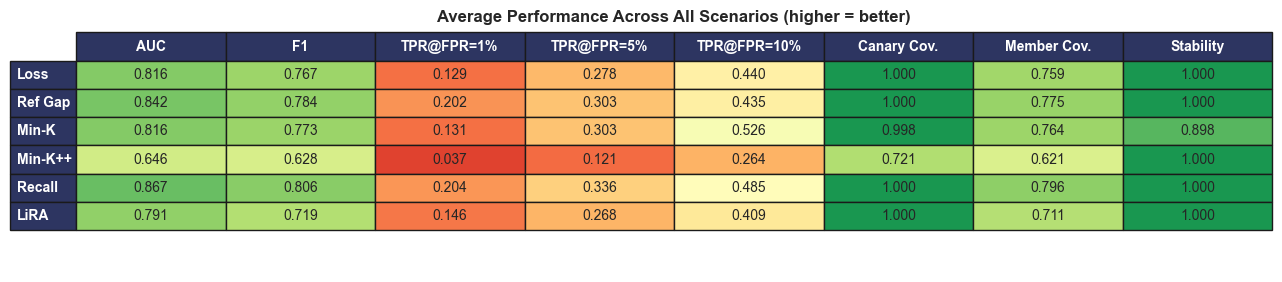


Note: Averaged across all models, datasets, and repetition levels.


In [4]:
# ── Attack × Metric overview table ───────────────────────────────────────────
# Averaged across all models, datasets, and canary reps — big picture view

key_metrics = ["auc", "f1", "tpr@fpr=0.01", "tpr@fpr=0.05", "tpr@fpr=0.10",
               "coverage_canaries", "coverage_all_members", "stability"]

overview = (metrics_df.groupby("attack")[key_metrics]
            .mean()
            .reindex(index=["loss", "ref_gap", "min_k", "min_k_pp", "recall", "lira"])
            .rename(columns={
                "auc": "AUC",
                "f1": "F1",
                "tpr@fpr=0.01": "TPR@FPR=1%",
                "tpr@fpr=0.05": "TPR@FPR=5%",
                "tpr@fpr=0.10": "TPR@FPR=10%",
                "coverage_canaries": "Canary Cov.",
                "coverage_all_members": "Member Cov.",
                "stability": "Stability",
            })
            .rename(index=ATTACK_LABELS))

# Pre-compute colour matrix from numpy values — avoids per-cell string parsing
vals_arr = overview.values.clip(0, 1)  # shape (n_rows, n_cols)
color_matrix = plt.cm.RdYlGn(vals_arr * 0.8 + 0.1)  # vectorised RGBA array

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")
tbl = ax.table(
    cellText=[[f"{v:.3f}" for v in row] for row in overview.values],
    rowLabels=overview.index.tolist(),
    colLabels=overview.columns.tolist(),
    cellLoc="center",
    loc="upper center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)

# Apply colours in one pass using the pre-computed matrix
celld = tbl.get_celld()
for (row, col), cell in celld.items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2d3561")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        cell.set_facecolor(color_matrix[row - 1, col])

ax.set_title("Average Performance Across All Scenarios (higher = better)",
             fontsize=12, fontweight="bold", pad=4)
plt.tight_layout()
plt.show()
print("\nNote: Averaged across all models, datasets, and repetition levels.")


## 3. Multi-Metric Performance Landscape

Heatmaps showing how each attack performs across models and datasets using multiple metrics simultaneously — not just AUC.

### AUC (averaged across all canary repetitions)


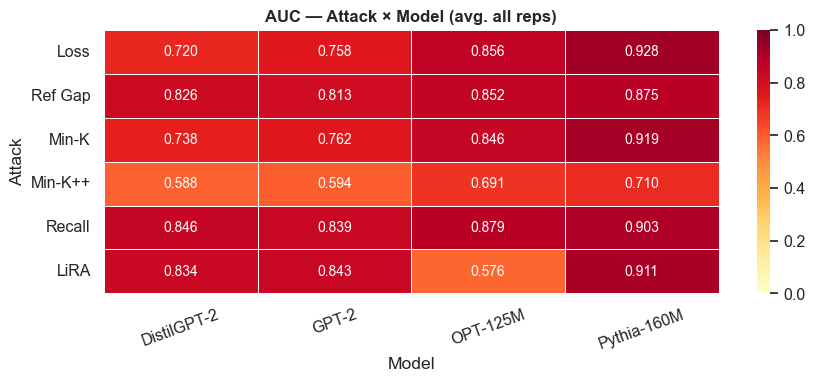

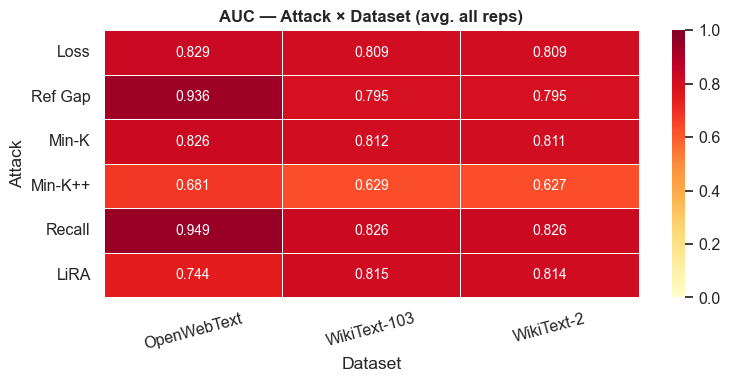

In [5]:
def heatmap_attack_x_model(metric: str, title: str, canary_rep=None, vmin=0, vmax=1, cmap="YlOrRd"):
    """Plot a heatmap of attack (rows) × model (columns) for a given metric."""
    subset = metrics_df.copy()
    if canary_rep is not None:
        subset = subset[subset["canary_rep"] == canary_rep]
    
    pivot = (subset.groupby(["attack", "model_short"])[metric]
             .mean()
             .unstack("model_short"))
    
    # Reorder
    attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.index]
    model_order  = sorted(pivot.columns, key=lambda m: MODELS_ORDER.index(m)
                          if m in MODELS_ORDER else 99)
    pivot = pivot.loc[attack_order, [m for m in model_order if m in pivot.columns]]
    pivot.index = [ATTACK_LABELS.get(a, a) for a in pivot.index]
    pivot.columns = [MODEL_LABELS.get(c, c) for c in pivot.columns]
    
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, vmin=vmin, vmax=vmax,
                ax=ax, linewidths=0.5, annot_kws={"size": 10})
    label = f"(r={canary_rep})" if canary_rep else "(avg. all reps)"
    ax.set_title(f"{title} — Attack × Model {label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Model"); ax.set_ylabel("Attack")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()


def heatmap_attack_x_dataset(metric: str, title: str, canary_rep=None, vmin=0, vmax=1, cmap="YlOrRd"):
    """Plot a heatmap of attack (rows) × dataset (columns) for a given metric."""
    subset = metrics_df.copy()
    if canary_rep is not None:
        subset = subset[subset["canary_rep"] == canary_rep]
    
    pivot = (subset.groupby(["attack", "dataset"])[metric]
             .mean()
             .unstack("dataset"))
    
    attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.index]
    pivot = pivot.loc[attack_order]
    pivot.index = [ATTACK_LABELS.get(a, a) for a in pivot.index]
    pivot.columns = [DATASET_LABELS.get(c, c) for c in pivot.columns]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, vmin=vmin, vmax=vmax,
                ax=ax, linewidths=0.5, annot_kws={"size": 10})
    label = f"(r={canary_rep})" if canary_rep else "(avg. all reps)"
    ax.set_title(f"{title} — Attack × Dataset {label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Dataset"); ax.set_ylabel("Attack")
    ax.tick_params(axis="x", rotation=15)
    plt.tight_layout()
    plt.show()


# ── 3a: AUC heatmaps ──────────────────────────────────────────────────────────
print("### AUC (averaged across all canary repetitions)")
heatmap_attack_x_model("auc", "AUC")
heatmap_attack_x_dataset("auc", "AUC")


### TPR @ 1% FPR — the key metric for practical privacy risk


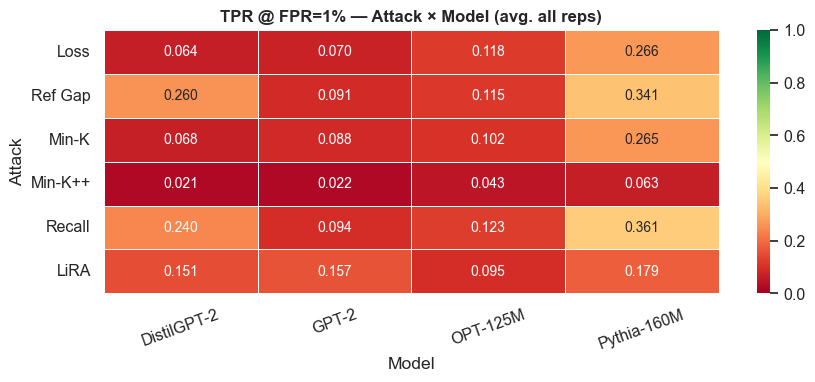

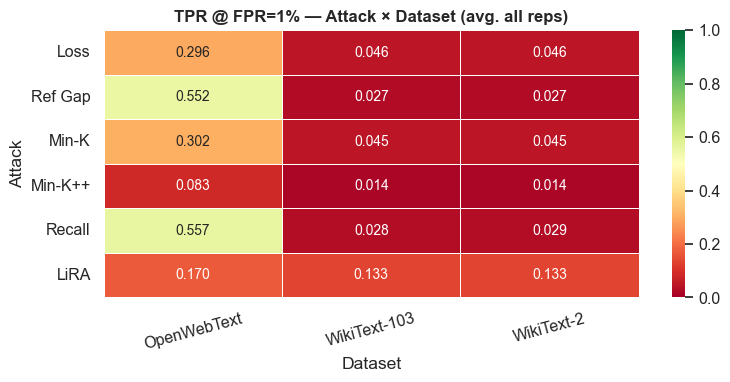

In [6]:
# ── 3b: TPR at low FPR heatmaps (the operational metric) ─────────────────────
print("### TPR @ 1% FPR — the key metric for practical privacy risk")
heatmap_attack_x_model("tpr@fpr=0.01", "TPR @ FPR=1%", cmap="RdYlGn")
heatmap_attack_x_dataset("tpr@fpr=0.01", "TPR @ FPR=1%", cmap="RdYlGn")


### Canary Coverage vs. All-Member Coverage — attack selectivity


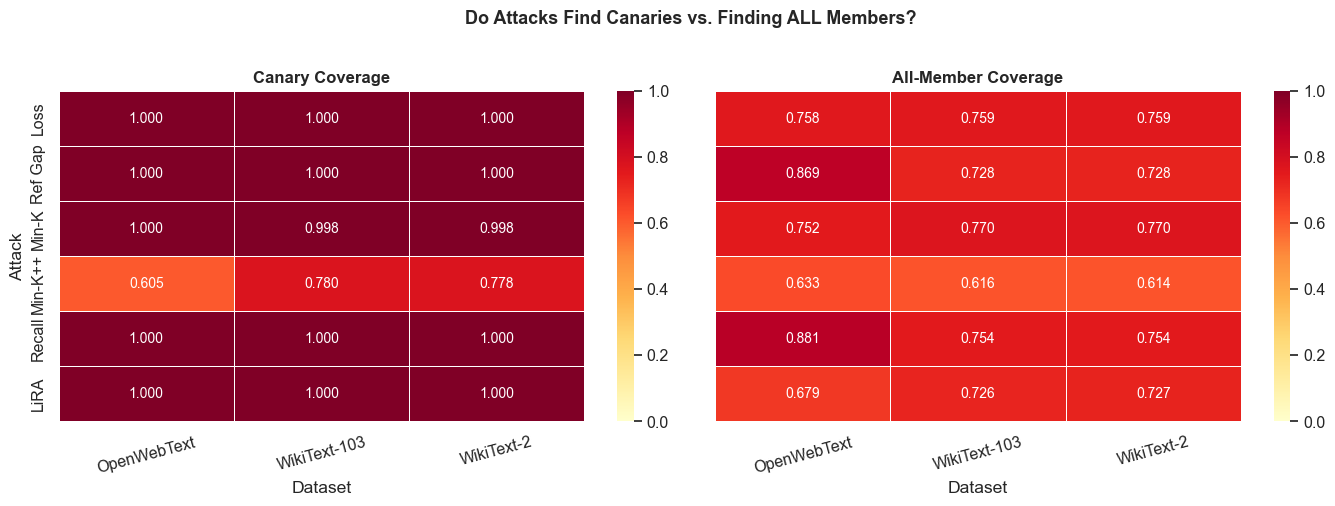


→ A high canary-coverage / low member-coverage gap means the attack is
  specifically exploiting repetition, not general memorisation.


In [7]:
# ── 3c: Canary coverage vs member coverage ────────────────────────────────────
print("### Canary Coverage vs. All-Member Coverage — attack selectivity")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, metric, label in zip(axes,
                              ["coverage_canaries", "coverage_all_members"],
                              ["Canary Coverage", "All-Member Coverage"]):
    pivot = (metrics_df.groupby(["attack", "dataset"])[metric]
             .mean()
             .unstack("dataset"))
    attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.index]
    pivot = pivot.loc[attack_order]
    pivot.index = [ATTACK_LABELS.get(a, a) for a in pivot.index]
    pivot.columns = [DATASET_LABELS.get(c, c) for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0, vmax=1,
                ax=ax, linewidths=0.5, annot_kws={"size": 10})
    ax.set_title(label, fontsize=12, fontweight="bold")
    ax.set_xlabel("Dataset")
    ax.tick_params(axis="x", rotation=15)

axes[0].set_ylabel("Attack")
axes[1].set_ylabel("")
fig.suptitle("Do Attacks Find Canaries vs. Finding ALL Members?", 
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n→ A high canary-coverage / low member-coverage gap means the attack is")
print("  specifically exploiting repetition, not general memorisation.")


### Stability — how consistent are predictions across runs?


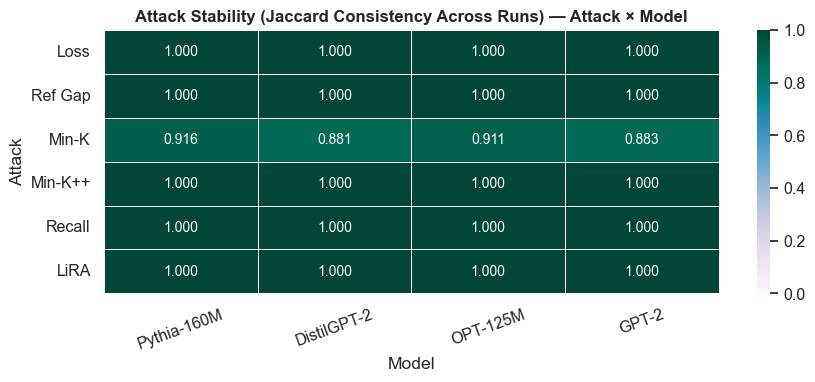


→ Stability < 1 means different samples are flagged on different runs.
  Random attacks (stochastic) like Min-K may show lower stability.


In [8]:
# ── 3d: Stability heatmap ─────────────────────────────────────────────────────
print("### Stability — how consistent are predictions across runs?")

pivot = (metrics_df.groupby(["attack", "model_short"])["stability"]
         .mean()
         .unstack("model_short"))
attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.index]
pivot = pivot.loc[attack_order]
pivot.index = [ATTACK_LABELS.get(a, a) for a in pivot.index]
pivot.columns = [MODEL_LABELS.get(c, c) for c in pivot.columns]

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="PuBuGn", vmin=0, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={"size": 10})
ax.set_title("Attack Stability (Jaccard Consistency Across Runs) — Attack × Model",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Model"); ax.set_ylabel("Attack")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("\n→ Stability < 1 means different samples are flagged on different runs.")
print("  Random attacks (stochastic) like Min-K may show lower stability.")


## 4. ROC Curves & Score Separability

ROC curves computed directly from per-sample scores, overlaid across attacks for each (model, dataset, repetition) scenario. These reveal not just AUC but the *shape* of the detection curve — critical for understanding behaviour at specific operating points.

### ROC Curves at canary_rep=1 — all models and datasets


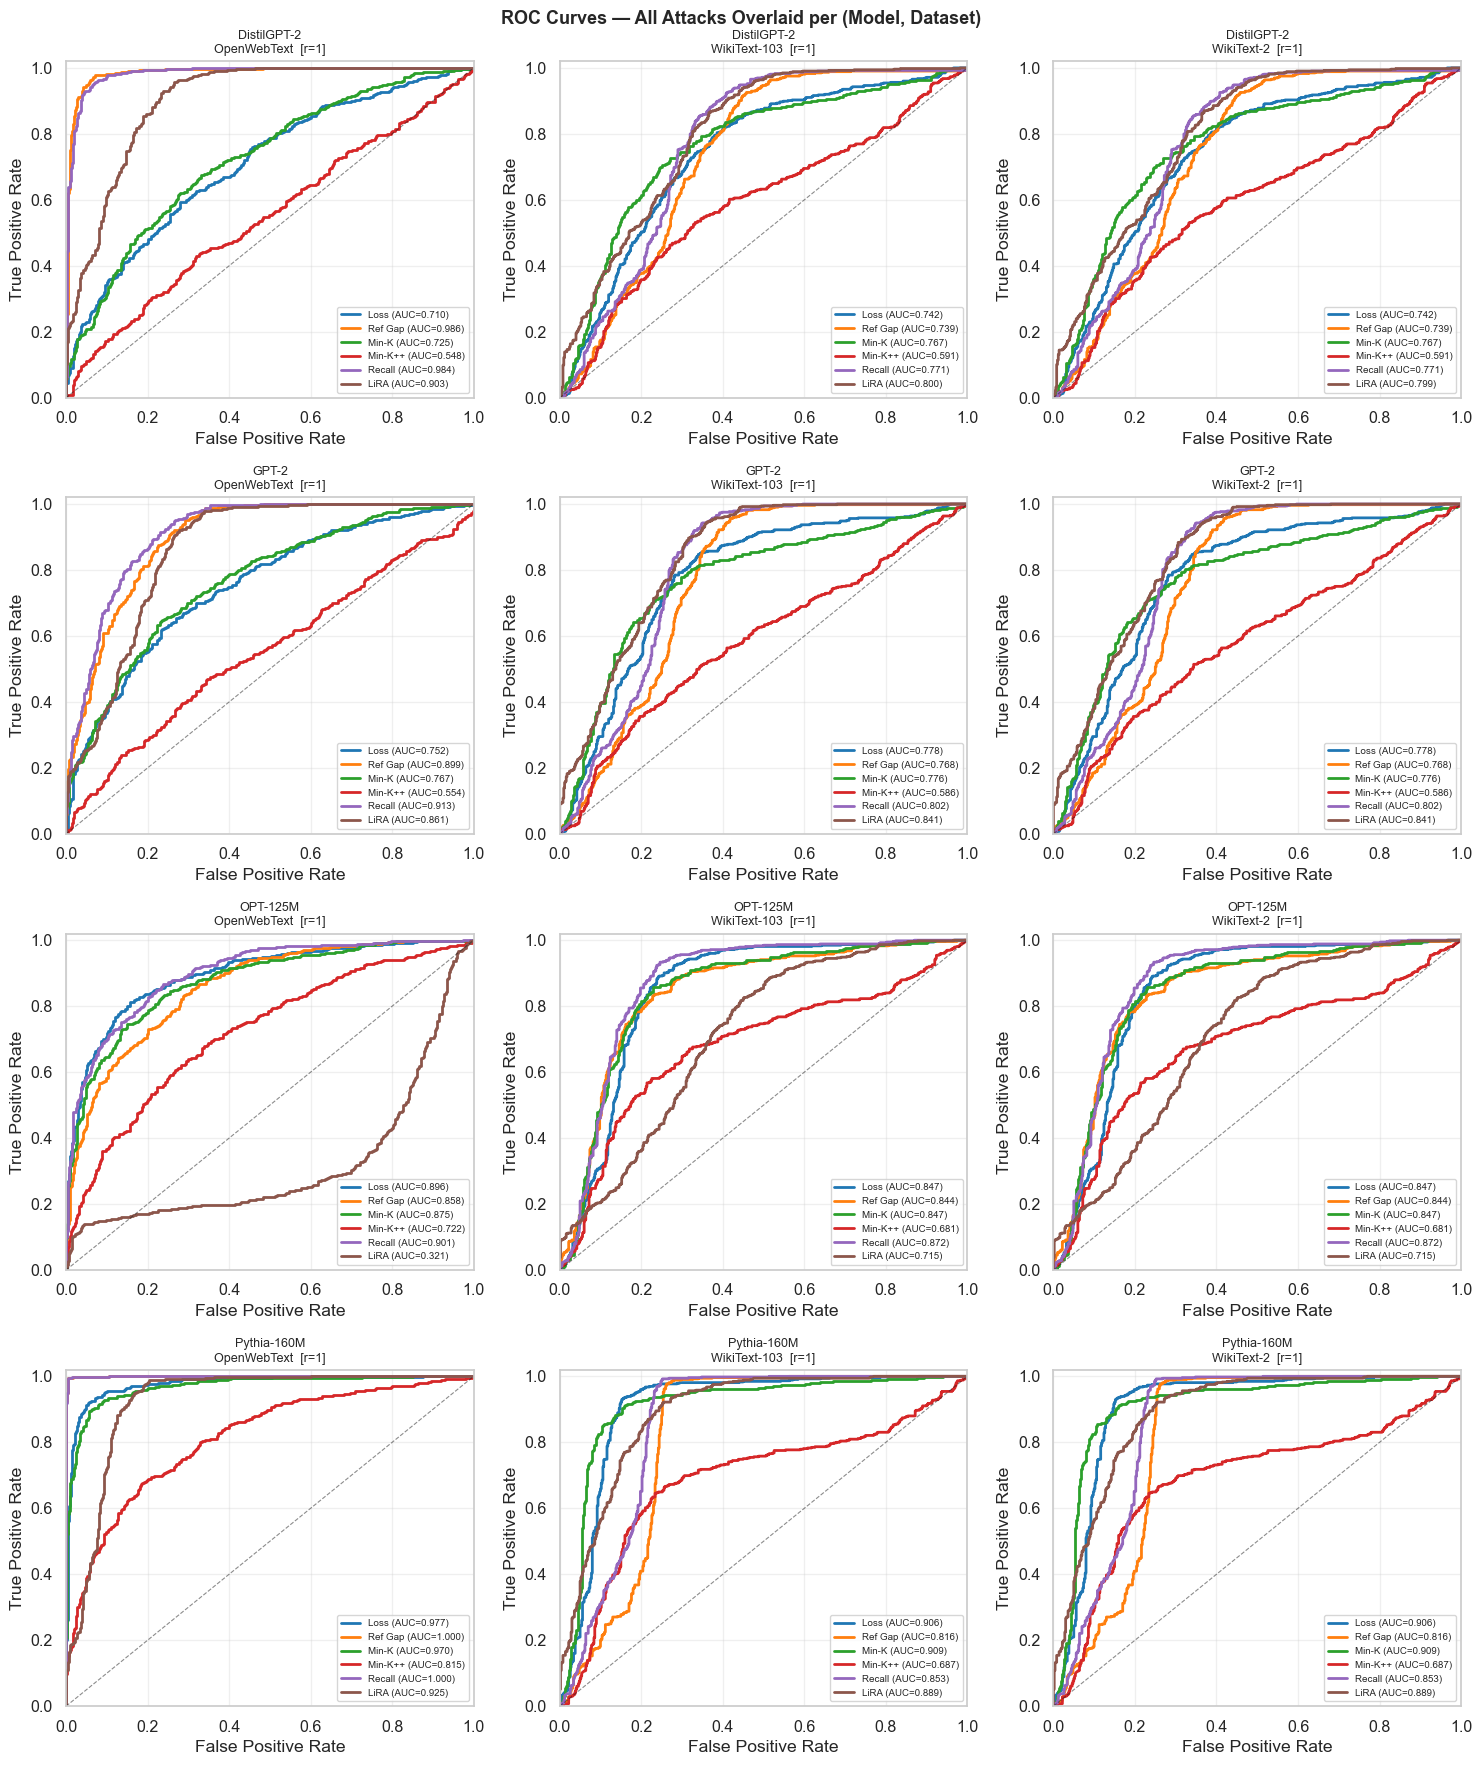

In [9]:
def compute_roc_from_scores(df_subset, attack):
    """Compute ROC from score rows for a single attack."""
    d = df_subset[df_subset["attack"] == attack].copy()
    if len(d) < 10:
        return None, None, None
    d = d.drop_duplicates(subset=["sample_id", "run"]) if "run" in d.columns else d
    # average score per sample across runs
    d = d.groupby(["sample_id", "label"])["score"].mean().reset_index()
    labels = d["label"].values
    scores = d["score"].values
    if len(set(labels)) < 2:
        return None, None, None
    smaller = ATTACK_SMALLER_IS_MEMBER.get(attack, True)
    s = -scores if smaller else scores
    try:
        fpr, tpr, _ = roc_curve(labels, s)
        auc_val = sklearn_auc(fpr, tpr)
        return fpr, tpr, auc_val
    except Exception:
        return None, None, None


def plot_roc_grid(model_filter=None, rep_filter=None, ncols=3):
    """Grid of ROC plots: one subplot per dataset, all attacks on each."""
    datasets = sorted(scores_df["dataset_clean"].unique())
    models   = sorted(scores_df["model_clean"].unique()) if model_filter is None else [model_filter]
    reps     = sorted(scores_df["canary_rep_int"].unique()) if rep_filter is None else [rep_filter]
    attacks  = sorted(scores_df["attack"].unique()) if "attack" in scores_df.columns else []

    nrows = len(models)
    ncols = len(datasets)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5), squeeze=False)

    for i, model in enumerate(models):
        for j, dataset in enumerate(datasets):
            ax = axes[i][j]
            for attack in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]:
                if attack not in attacks:
                    continue
                sub = scores_df[
                    (scores_df["model_clean"] == model) &
                    (scores_df["dataset_clean"] == dataset) &
                    (scores_df["canary_rep_int"].isin(reps))
                ]
                fpr, tpr, auc_val = compute_roc_from_scores(sub, attack)
                if fpr is None:
                    continue
                ax.plot(fpr, tpr, color=ATTACK_COLORS[attack], lw=2,
                        label=f"{ATTACK_LABELS[attack]} (AUC={auc_val:.3f})")
            ax.plot([0,1],[0,1],"k--", lw=0.8, alpha=0.5)
            ax.set_xlim(0,1); ax.set_ylim(0,1.02)
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            title_model = MODEL_LABELS.get(model, model)
            title_ds    = DATASET_LABELS.get(dataset, dataset)
            rep_str = f"r={reps[0]}" if len(reps)==1 else "all reps"
            ax.set_title(f"{title_model}\n{title_ds}  [{rep_str}]", fontsize=9)
            ax.legend(fontsize=7, loc="lower right")
            ax.grid(alpha=0.3)

    fig.suptitle("ROC Curves — All Attacks Overlaid per (Model, Dataset)", 
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# Full ROC grid at r=1 (all models, all datasets)
print("### ROC Curves at canary_rep=1 — all models and datasets")
plot_roc_grid(rep_filter=1)


### ROC Curves at canary_rep=8 — do more repetitions uniformly shift curves?


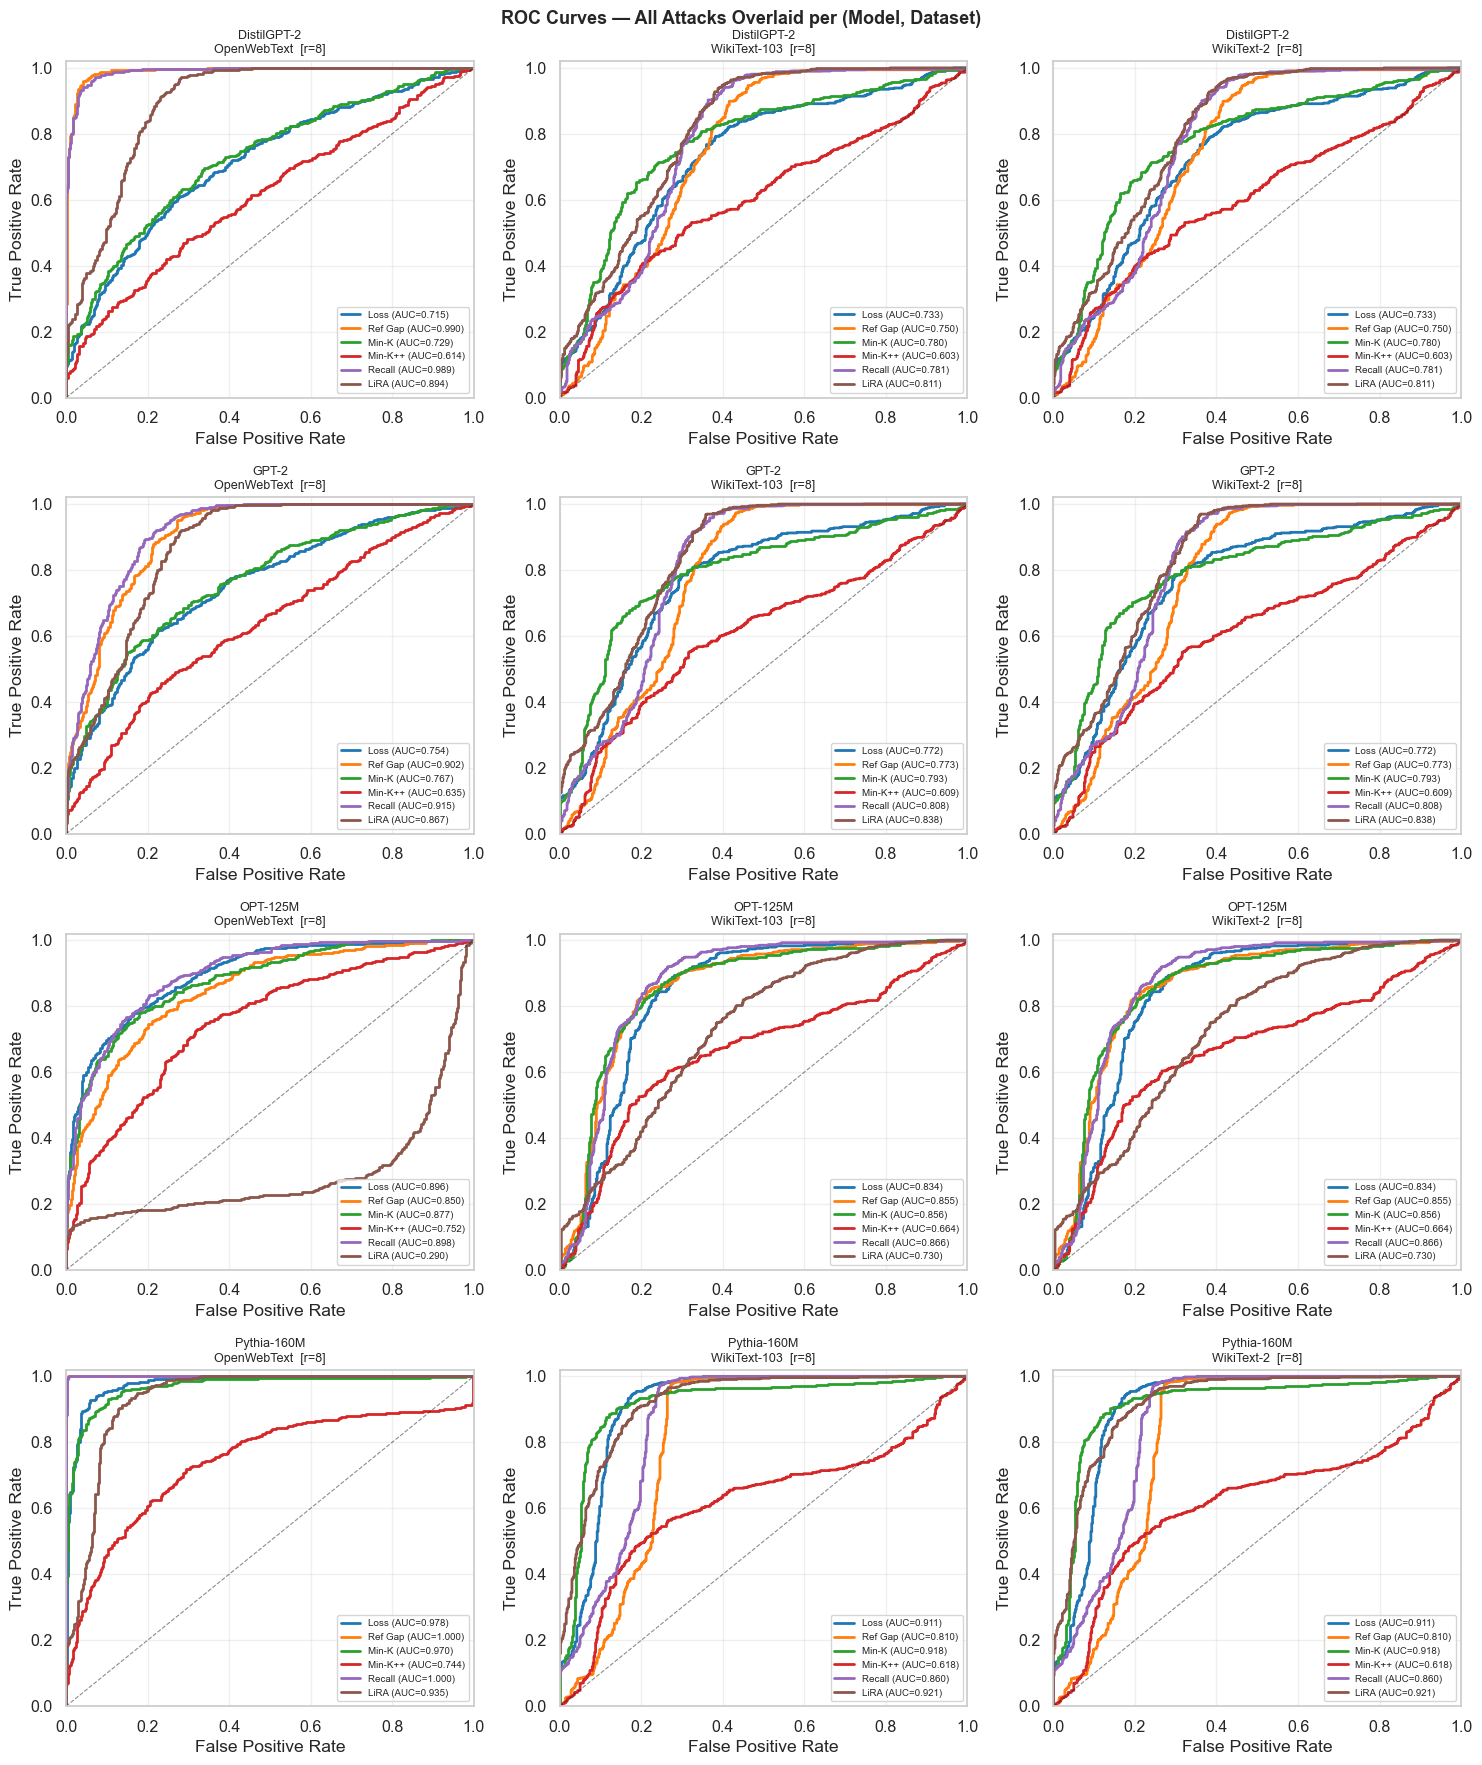

In [10]:
# ── ROC at r=8 for comparison ─────────────────────────────────────────────────
print("### ROC Curves at canary_rep=8 — do more repetitions uniformly shift curves?")
plot_roc_grid(rep_filter=8)


### ROC Curves — Zoomed into low FPR region [0, 0.10]
This region is most relevant for real-world adversarial settings.



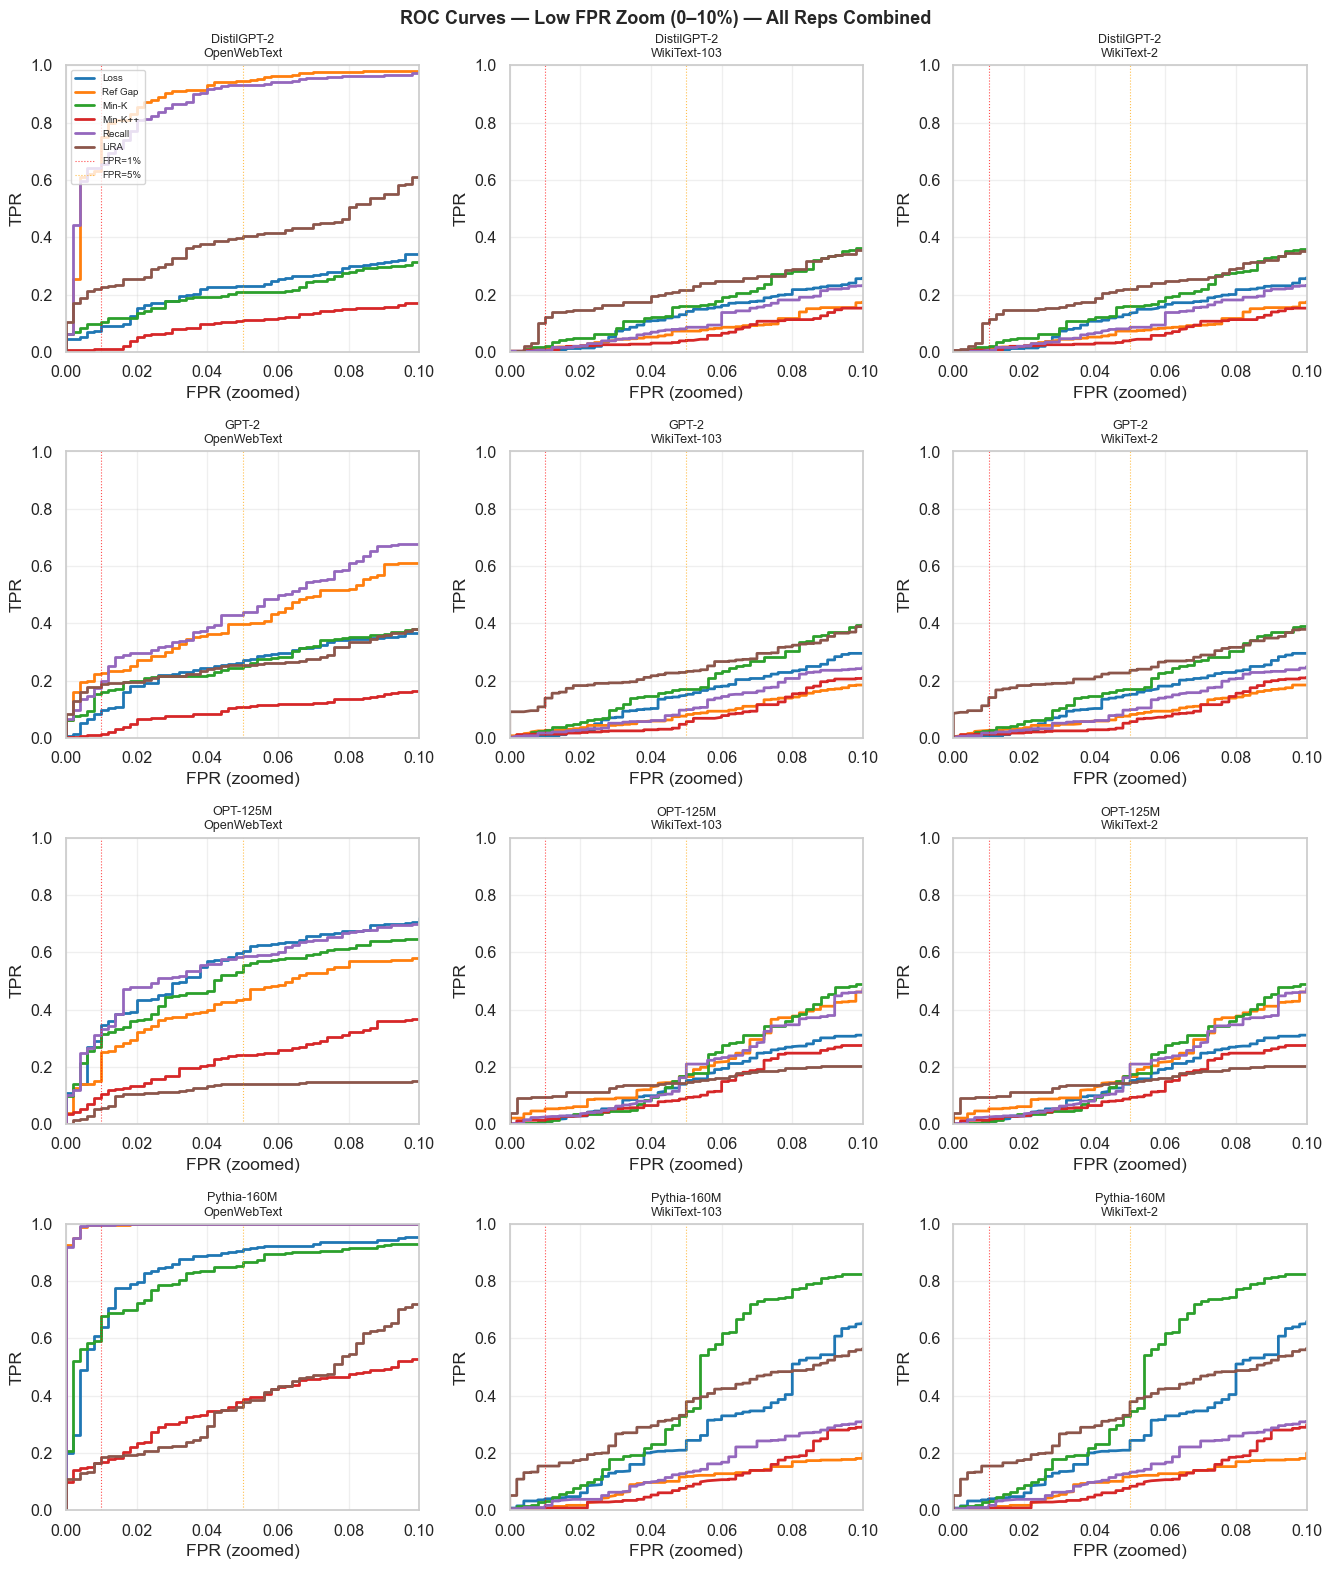

In [11]:
# ── Low-FPR zoom: the tail that matters for privacy ─────────────────────────
print("### ROC Curves — Zoomed into low FPR region [0, 0.10]")
print("This region is most relevant for real-world adversarial settings.\n")

datasets = sorted(scores_df["dataset_clean"].unique())
models   = sorted(scores_df["model_clean"].unique())

fig, axes = plt.subplots(len(models), len(datasets),
                         figsize=(len(datasets)*4.5, len(models)*4), squeeze=False)

for i, model in enumerate(models):
    for j, dataset in enumerate(datasets):
        ax = axes[i][j]
        for attack in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]:
            if "attack" not in scores_df.columns or attack not in scores_df["attack"].unique():
                continue
            sub = scores_df[
                (scores_df["model_clean"] == model) &
                (scores_df["dataset_clean"] == dataset)
            ]
            fpr, tpr, auc_val = compute_roc_from_scores(sub, attack)
            if fpr is None:
                continue
            ax.plot(fpr, tpr, color=ATTACK_COLORS[attack], lw=2,
                    label=f"{ATTACK_LABELS[attack]}")
        ax.set_xlim(0, 0.10); ax.set_ylim(0, 1.0)
        ax.axvline(0.01, color="red",  lw=0.8, ls=":", alpha=0.7, label="FPR=1%")
        ax.axvline(0.05, color="orange", lw=0.8, ls=":", alpha=0.7, label="FPR=5%")
        ax.set_xlabel("FPR (zoomed)")
        ax.set_ylabel("TPR")
        ax.set_title(f"{MODEL_LABELS.get(model, model)}\n{DATASET_LABELS.get(dataset, dataset)}",
                     fontsize=9)
        if i == 0 and j == 0:
            ax.legend(fontsize=7, loc="upper left")
        ax.grid(alpha=0.3)

fig.suptitle("ROC Curves — Low FPR Zoom (0–10%) — All Reps Combined",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 5. Score Distribution Analysis

Understanding *how* each attack separates members from non-members — not just whether it can. This section examines the score distributions, their overlap, and how canaries are positioned relative to regular members.

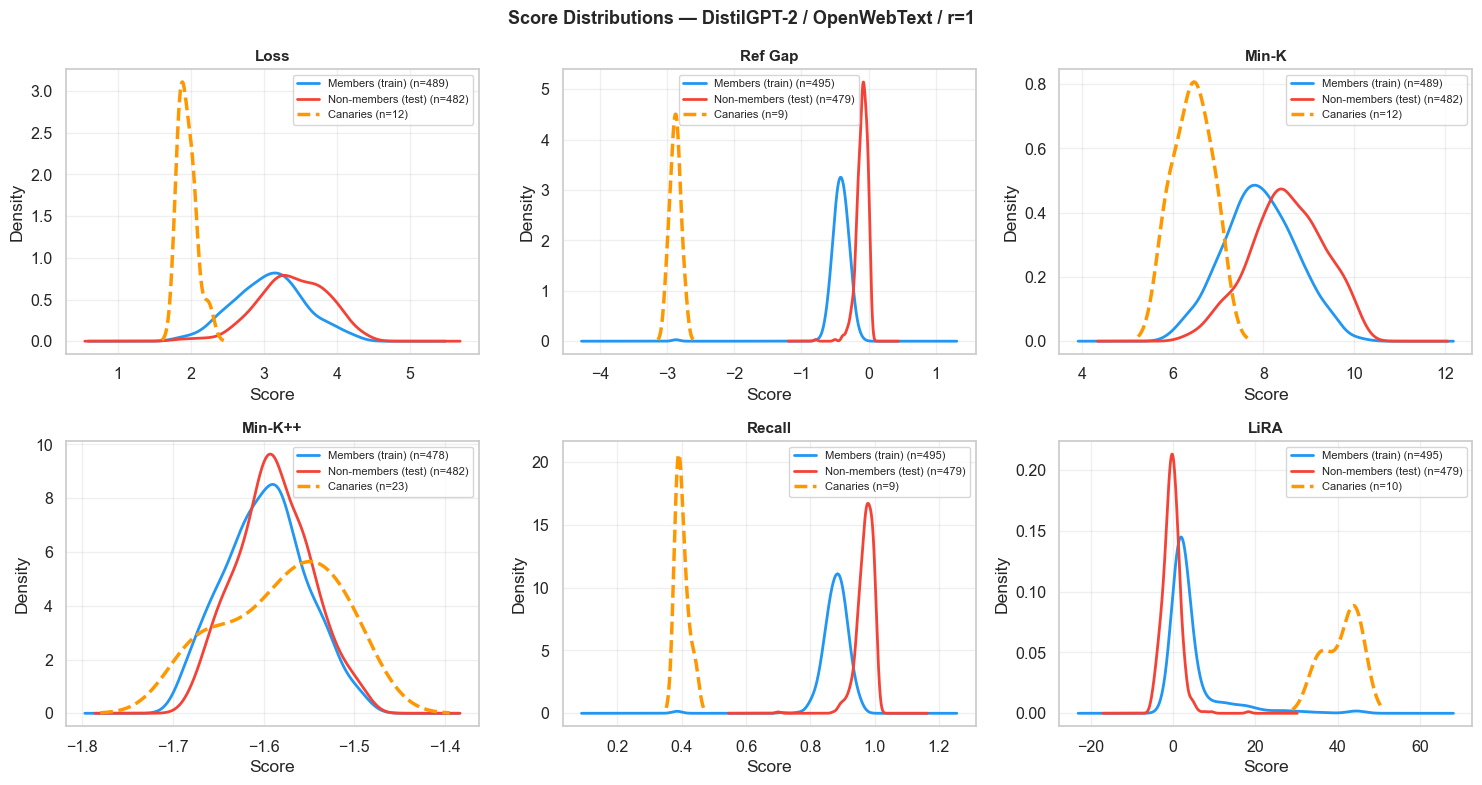

In [12]:
def plot_score_distributions(model_filter, dataset_filter, rep_filter=1, clip_quantile=0.02):
    """KDE plots of score distributions per attack, with members / non-members / canaries."""
    attacks_order = ["loss", "ref_gap", "min_k", "min_k_pp", "recall", "lira"]
    n = len(attacks_order)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()

    sub = scores_df[
        (scores_df["model_clean"] == model_filter) &
        (scores_df["dataset_clean"] == dataset_filter) &
        (scores_df["canary_rep_int"] == rep_filter)
    ]

    for ax, attack in zip(axes, attacks_order):
        d = sub[sub["attack"] == attack].copy()
        if d.empty:
            ax.set_visible(False)
            continue

        # Average across runs
        d = d.groupby(["sample_id", "source", "label"])["score"].mean().reset_index()
        lo = d["score"].quantile(clip_quantile)
        hi = d["score"].quantile(1 - clip_quantile)
        d = d[(d["score"] >= lo) & (d["score"] <= hi)]

        members    = d[d["source"] == "train"]["score"]
        nonmembers = d[d["source"] == "test"]["score"]
        canaries   = d[d["source"] == "canary"]["score"]

        for scores_s, label, color, lw, ls in [
            (members,    "Members (train)",  "#2196F3", 2.0, "-"),
            (nonmembers, "Non-members (test)", "#F44336", 2.0, "-"),
            (canaries,   "Canaries",          "#FF9800", 2.5, "--"),
        ]:
            if len(scores_s) < 5:
                continue
            scores_s.plot.kde(ax=ax, color=color, lw=lw, ls=ls, label=f"{label} (n={len(scores_s)})")

        ax.set_title(f"{ATTACK_LABELS.get(attack, attack)}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Score")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    title = (f"Score Distributions — {MODEL_LABELS.get(model_filter, model_filter)}"
             f" / {DATASET_LABELS.get(dataset_filter, dataset_filter)}"
             f" / r={rep_filter}")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_score_distributions("distilgpt2", "openwebtext", rep_filter=1)

### Score distributions — Ref Gap attack, all models, all reps combined



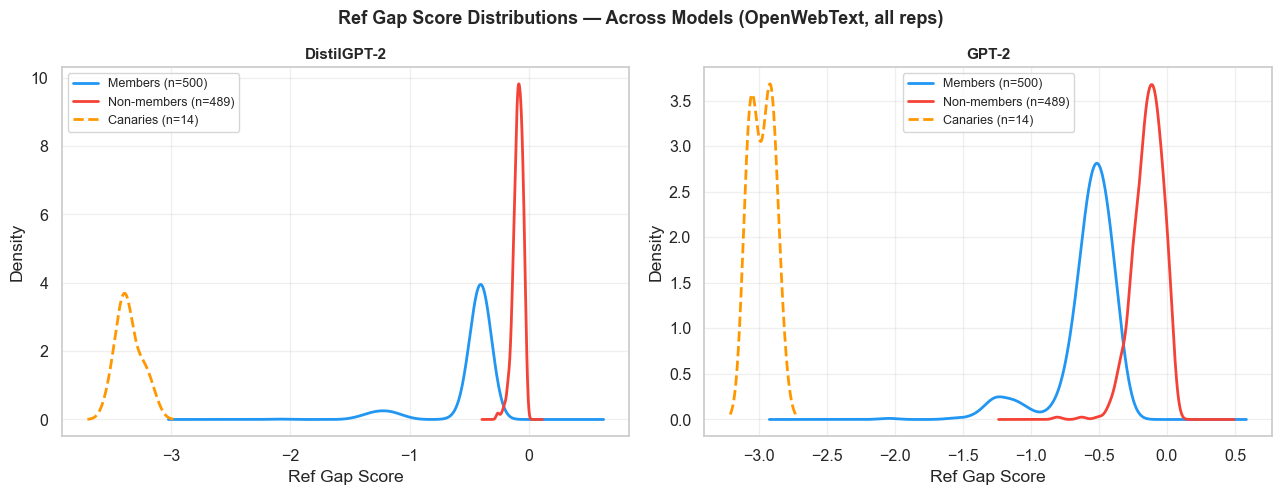

In [13]:
# ── Score distributions across all models (one attack, one dataset) ──────────
print("### Score distributions — Ref Gap attack, all models, all reps combined\n")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
attack = "ref_gap"

for ax, model in zip(axes.flatten(), MODELS_ORDER):
    sub = scores_df[
        (scores_df["model_clean"] == model) &
        (scores_df["dataset_clean"] == "openwebtext") &
        (scores_df["attack"] == attack)
    ]
    if sub.empty:
        ax.set_visible(False)
        continue
    d = sub.groupby(["sample_id", "source", "label"])["score"].mean().reset_index()
    lo, hi = d["score"].quantile(0.01), d["score"].quantile(0.99)
    d = d[(d["score"] >= lo) & (d["score"] <= hi)]

    for src, label, color, ls in [
        ("train",  "Members",     "#2196F3", "-"),
        ("test",   "Non-members", "#F44336", "-"),
        ("canary", "Canaries",    "#FF9800", "--"),
    ]:
        scores_s = d[d["source"] == src]["score"]
        if len(scores_s) < 5:
            continue
        scores_s.plot.kde(ax=ax, color=color, lw=2, ls=ls,
                          label=f"{label} (n={len(scores_s)})")

    ax.set_title(f"{MODEL_LABELS.get(model, model)}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Ref Gap Score")
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle("Ref Gap Score Distributions — Across Models (OpenWebText, all reps)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Distribution Overlap — Bhattacharyya Coefficient

Measures how much member/non-member score distributions overlap.
Lower value = better separation. 0 = perfect separation, 1 = identical.



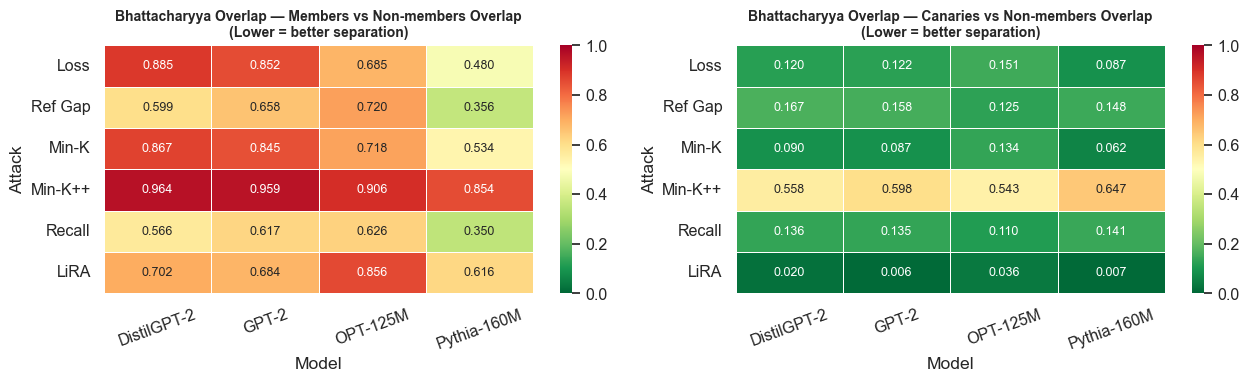

In [14]:
# ── Distribution overlap quantification ──────────────────────────────────────
print("### Distribution Overlap — Bhattacharyya Coefficient\n")
print("Measures how much member/non-member score distributions overlap.")
print("Lower value = better separation. 0 = perfect separation, 1 = identical.\n")

def bhattacharyya_coeff(a, b, n_bins=50):
    """Bhattacharyya coefficient between two distributions."""
    a, b = np.array(a, dtype=float), np.array(b, dtype=float)
    lo = min(a.min(), b.min()); hi = max(a.max(), b.max())
    if lo == hi:
        return 1.0
    bins = np.linspace(lo, hi, n_bins + 1)
    ha, _ = np.histogram(a, bins=bins, density=True)
    hb, _ = np.histogram(b, bins=bins, density=True)
    bin_w = bins[1] - bins[0]
    bc = np.sum(np.sqrt(ha * hb)) * bin_w
    return float(np.clip(bc, 0, 1))


overlap_rows = []
for (model, dataset, rep, attack), grp in scores_df.groupby(
        ["model_clean", "dataset_clean", "canary_rep_int", "attack"]):
    d = grp.groupby(["sample_id", "source"])["score"].mean().reset_index()
    mem = d[d["source"] == "train"]["score"].dropna()
    non = d[d["source"] == "test"]["score"].dropna()
    can = d[d["source"] == "canary"]["score"].dropna()
    if len(mem) < 10 or len(non) < 10:
        continue
    overlap_rows.append({
        "model":      model,
        "dataset":    dataset,
        "canary_rep": rep,
        "attack":     attack,
        "overlap_mem_non": bhattacharyya_coeff(mem, non),
        "overlap_can_non": bhattacharyya_coeff(can, non) if len(can) >= 3 else np.nan,
    })

overlap_df = pd.DataFrame(overlap_rows)

# Heatmap: mean overlap across all scenarios per attack
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label in zip(axes,
    ["overlap_mem_non", "overlap_can_non"],
    ["Members vs Non-members Overlap", "Canaries vs Non-members Overlap"]):
    pivot = (overlap_df.groupby(["attack", "model"])[col]
             .mean().unstack("model"))
    attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.index]
    pivot = pivot.loc[attack_order]
    pivot.index = [ATTACK_LABELS.get(a,a) for a in pivot.index]
    pivot.columns = [MODEL_LABELS.get(c.split("/")[-1], c.split("/")[-1]) for c in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r", vmin=0, vmax=1,
                ax=ax, linewidths=0.5, annot_kws={"size": 9})
    ax.set_title(f"Bhattacharyya Overlap — {label}\n(Lower = better separation)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Model"); ax.set_ylabel("Attack")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


### Score Violin Plots — all attacks, all models (OpenWebText, r=1)



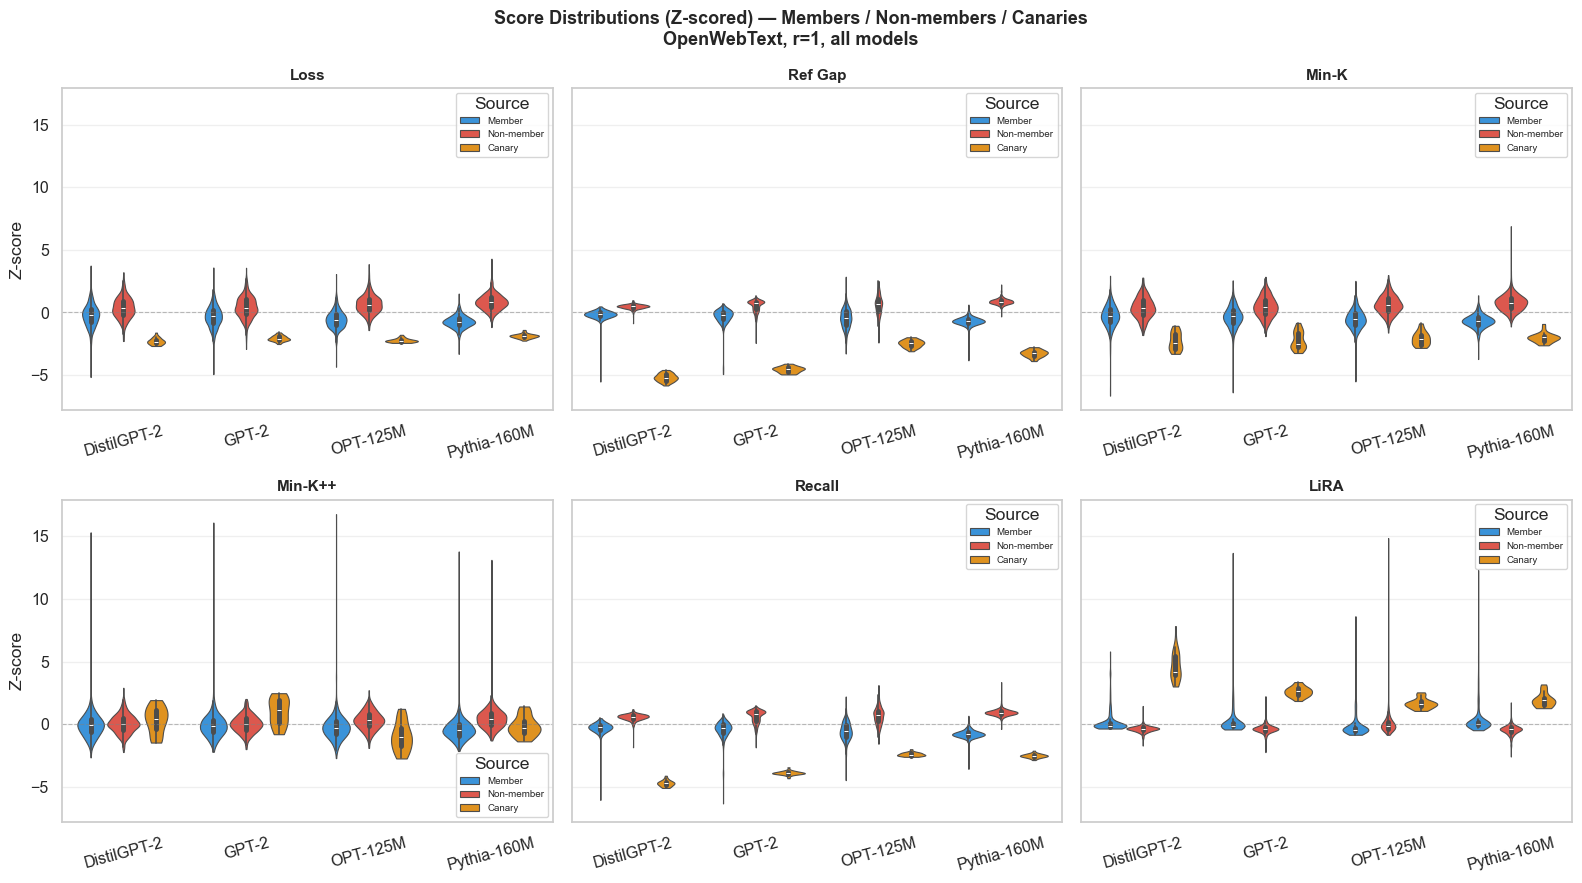

In [15]:
# ── Score violin plots: members vs non-members vs canaries ───────────────────
print("### Score Violin Plots — all attacks, all models (OpenWebText, r=1)\n")

attack_order = ["loss", "ref_gap", "min_k", "min_k_pp", "recall", "lira"]
sub = scores_df[
    (scores_df["dataset_clean"] == "openwebtext") &
    (scores_df["canary_rep_int"] == 1)
].copy()

if "attack" in sub.columns and not sub.empty:
    # Average across runs; use only the 6 attacks in order
    sub = sub[sub["attack"].isin(attack_order)]
    d = sub.groupby(["model_clean","attack","sample_id","source"])["score"].mean().reset_index()
    d["attack_label"] = d["attack"].map(ATTACK_LABELS)
    d["model_label"]  = d["model_clean"].map(lambda m: MODEL_LABELS.get(m, m))
    d["source_label"] = d["source"].map({"train":"Member","test":"Non-member","canary":"Canary"})

    # Normalise scores per (model,attack) to make cross-attack comparison valid
    def zscore(x): return (x - x.mean()) / (x.std() + 1e-10)
    d["score_z"] = d.groupby(["model_clean","attack"])["score"].transform(zscore)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)
    for ax, attack in zip(axes.flatten(), attack_order):
        dd = d[d["attack"] == attack]
        order = ["Member","Non-member","Canary"]
        palette = {"Member":"#2196F3","Non-member":"#F44336","Canary":"#FF9800"}
        
        # Use violin with inner box-plot whiskers
        sns.violinplot(data=dd, x="model_label", y="score_z",
                       hue="source_label", hue_order=order,
                       palette=palette, ax=ax, inner="box",
                       cut=0, linewidth=0.8, dodge=True, width=0.8)
        ax.set_title(f"{ATTACK_LABELS.get(attack,attack)}", fontsize=11, fontweight="bold")
        ax.set_xlabel(""); ax.set_ylabel("Z-score")
        ax.tick_params(axis="x", rotation=15)
        ax.legend(fontsize=7, title="Source")
        ax.grid(axis="y", alpha=0.3)
        ax.axhline(0, lw=0.8, ls="--", color="grey", alpha=0.5)

    fig.suptitle("Score Distributions (Z-scored) — Members / Non-members / Canaries\n"
                 "OpenWebText, r=1, all models", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


## 6. Canary Detection: Depth Analysis

Canaries are deliberately injected sequences repeated `r` times. This section asks: **which canaries get detected, by which attacks, and under what conditions?**

### Per-canary detection rate — which canaries are consistently found?



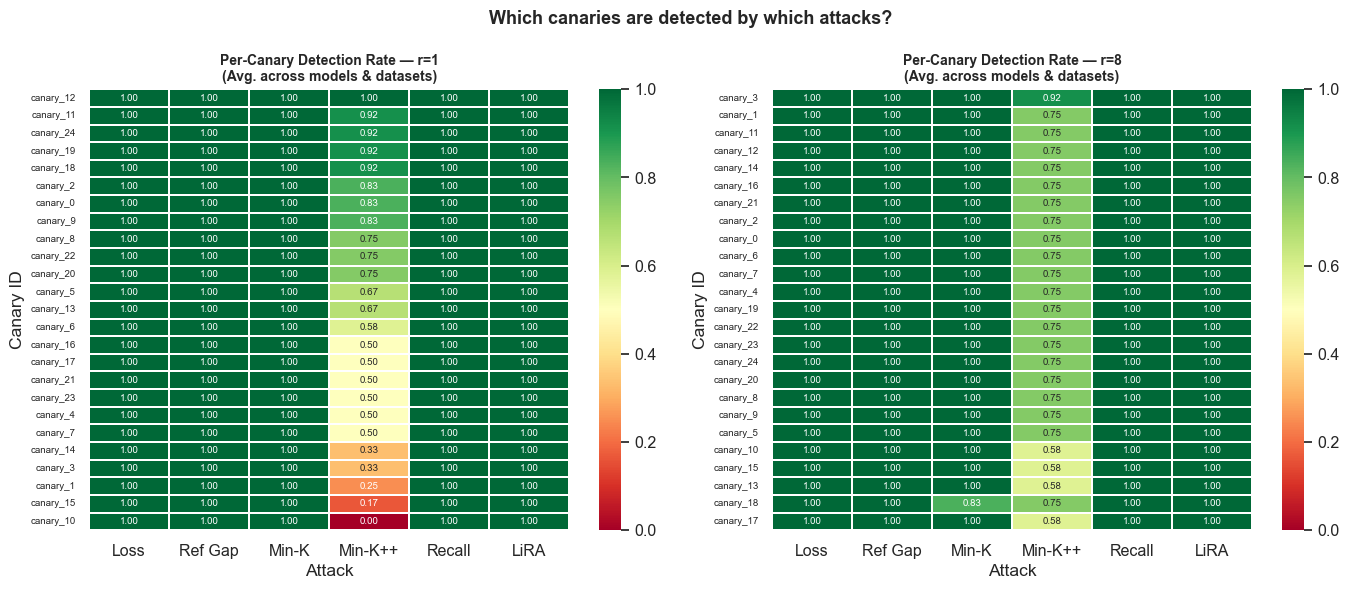


→ Rows sorted by average detection rate. Canaries at top are found by all attacks.
  Canaries at bottom are reliably missed — understanding why is key.


In [16]:
# ── Per-canary detection rate across attacks ──────────────────────────────────
print("### Per-canary detection rate — which canaries are consistently found?\n")

canaries_df = scores_df[scores_df["source"] == "canary"].copy()

if not canaries_df.empty:
    # Detection = prediction == 1
    det = (canaries_df.groupby(["model_clean","dataset_clean","canary_rep_int","attack","sample_id"])
           ["prediction"].mean()
           .reset_index()
           .rename(columns={"prediction": "detection_rate"}))

    # Average over models and datasets for a cleaner picture
    det_avg = det.groupby(["attack","sample_id","canary_rep_int"])["detection_rate"].mean().reset_index()

    # ── Heatmap: canary_id × attack, at r=1 and r=8 ──────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, rep in zip(axes, [1, 8]):
        d_rep = det_avg[det_avg["canary_rep_int"] == rep]
        if d_rep.empty:
            ax.set_visible(False)
            continue
        pivot = (d_rep.groupby(["sample_id","attack"])["detection_rate"]
                 .mean().unstack("attack"))
        attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.columns]
        pivot = pivot[attack_order]
        pivot.columns = [ATTACK_LABELS.get(a,a) for a in pivot.columns]
        # Sort rows by average detection rate
        pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]
        
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn",
                    vmin=0, vmax=1, ax=ax, linewidths=0.3,
                    annot_kws={"size": 7})
        ax.set_title(f"Per-Canary Detection Rate — r={rep}\n(Avg. across models & datasets)",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Attack"); ax.set_ylabel("Canary ID")
        ax.tick_params(axis="y", labelsize=7)

    fig.suptitle("Which canaries are detected by which attacks?", 
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("\n→ Rows sorted by average detection rate. Canaries at top are found by all attacks.")
    print("  Canaries at bottom are reliably missed — understanding why is key.")


### Where do canaries sit in the score space?



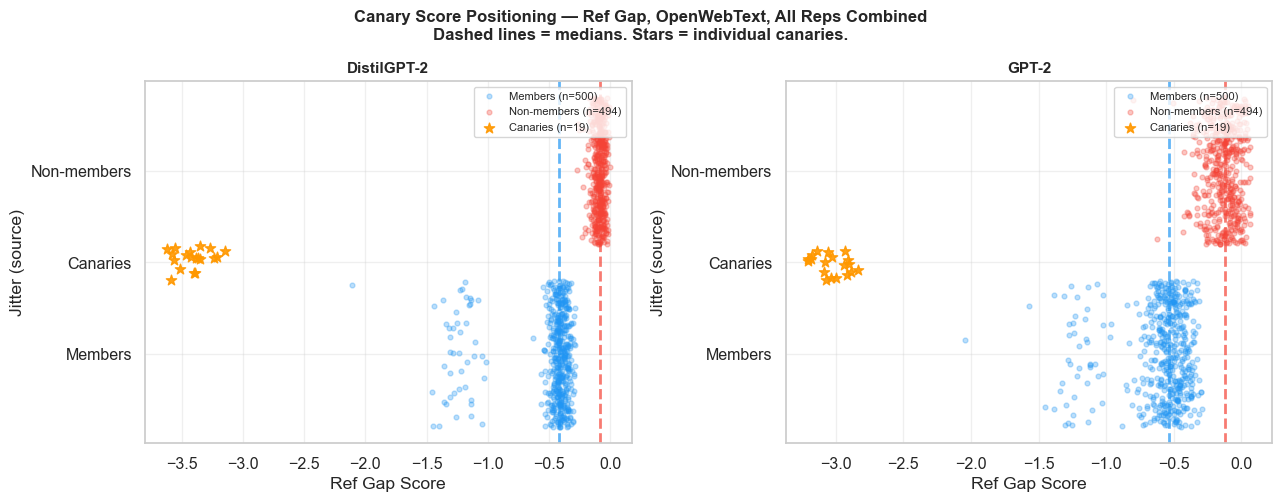

In [17]:
# ── Canary score positioning relative to members and non-members ─────────────
print("### Where do canaries sit in the score space?\n")

attack = "ref_gap"  # best performing reference attack
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, model in zip(axes.flatten(), MODELS_ORDER):
    # Get all reps combined
    sub = scores_df[
        (scores_df["model_clean"] == model) &
        (scores_df["dataset_clean"] == "openwebtext") &
        (scores_df["attack"] == attack)
    ].copy()
    if sub.empty:
        ax.set_visible(False)
        continue

    d = sub.groupby(["sample_id","source"])["score"].mean().reset_index()
    lo, hi = d["score"].quantile(0.005), d["score"].quantile(0.995)
    d = d[(d["score"] >= lo) & (d["score"] <= hi)]

    members    = d[d["source"] == "train"]["score"]
    nonmembers = d[d["source"] == "test"]["score"]
    canaries   = d[d["source"] == "canary"]["score"]

    ax.scatter(members, np.random.uniform(0.05, 0.45, len(members)),
               alpha=0.3, s=12, color="#2196F3", label=f"Members (n={len(members)})")
    ax.scatter(nonmembers, np.random.uniform(0.55, 0.95, len(nonmembers)),
               alpha=0.3, s=12, color="#F44336", label=f"Non-members (n={len(nonmembers)})")
    ax.scatter(canaries, np.random.uniform(0.45, 0.55, len(canaries)),
               alpha=0.9, s=60, color="#FF9800", zorder=5, marker="*",
               label=f"Canaries (n={len(canaries)})")

    # Median lines
    ax.axvline(members.median(),    color="#2196F3", lw=2, ls="--", alpha=0.7)
    ax.axvline(nonmembers.median(), color="#F44336", lw=2, ls="--", alpha=0.7)

    ax.set_title(f"{MODEL_LABELS.get(model, model)}", fontsize=11, fontweight="bold")
    ax.set_xlabel(f"Ref Gap Score")
    ax.set_ylabel("Jitter (source)")
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(["Members", "Canaries", "Non-members"])
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(alpha=0.3)

fig.suptitle("Canary Score Positioning — Ref Gap, OpenWebText, All Reps Combined\n"
             "Dashed lines = medians. Stars = individual canaries.",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Effect of Canary Repetitions

How does the number of times a canary is repeated during training affect detection rates? This section compares r=1, 2, 4, 8 across attacks.

### Canary Coverage vs. Canary Repetitions — per attack



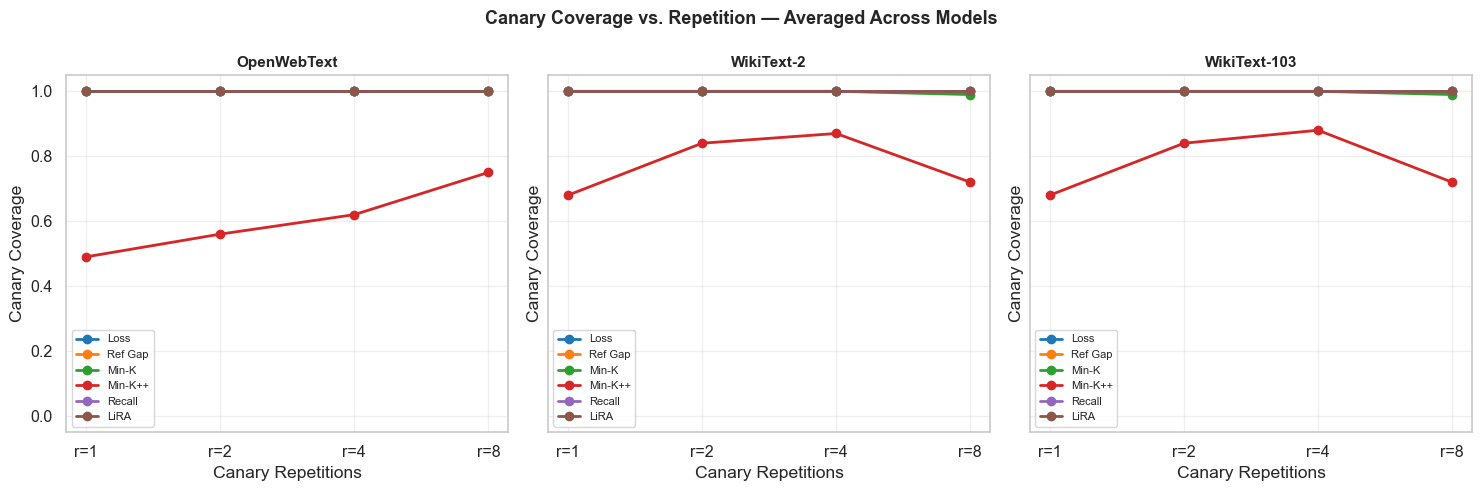

In [18]:
# ── Canary coverage vs repetition — line plots ───────────────────────────────
print("### Canary Coverage vs. Canary Repetitions — per attack\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, dataset in zip(axes, ["openwebtext", "wikitext-2-raw-v1", "wikitext-103-raw-v1"]):
    sub = metrics_df[metrics_df["dataset"] == dataset]
    for attack in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]:
        d = (sub[sub["attack"] == attack]
             .groupby("canary_rep")[["coverage_canaries","coverage_canaries_std"]]
             .mean()
             .reset_index()
             .sort_values("canary_rep"))
        if d.empty:
            continue
        ax.plot(d["canary_rep"], d["coverage_canaries"],
                marker="o", lw=2, color=ATTACK_COLORS[attack],
                label=ATTACK_LABELS[attack])
        ax.fill_between(d["canary_rep"],
                         d["coverage_canaries"] - d["coverage_canaries_std"],
                         d["coverage_canaries"] + d["coverage_canaries_std"],
                         alpha=0.12, color=ATTACK_COLORS[attack])

    ax.set_xscale("log", base=2)
    ax.set_xticks([1,2,4,8]); ax.set_xticklabels(["r=1","r=2","r=4","r=8"])
    ax.set_xlabel("Canary Repetitions")
    ax.set_ylabel("Canary Coverage")
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(DATASET_LABELS.get(dataset, dataset), fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("Canary Coverage vs. Repetition — Averaged Across Models",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### AUC vs. Canary Repetitions — per attack, per model



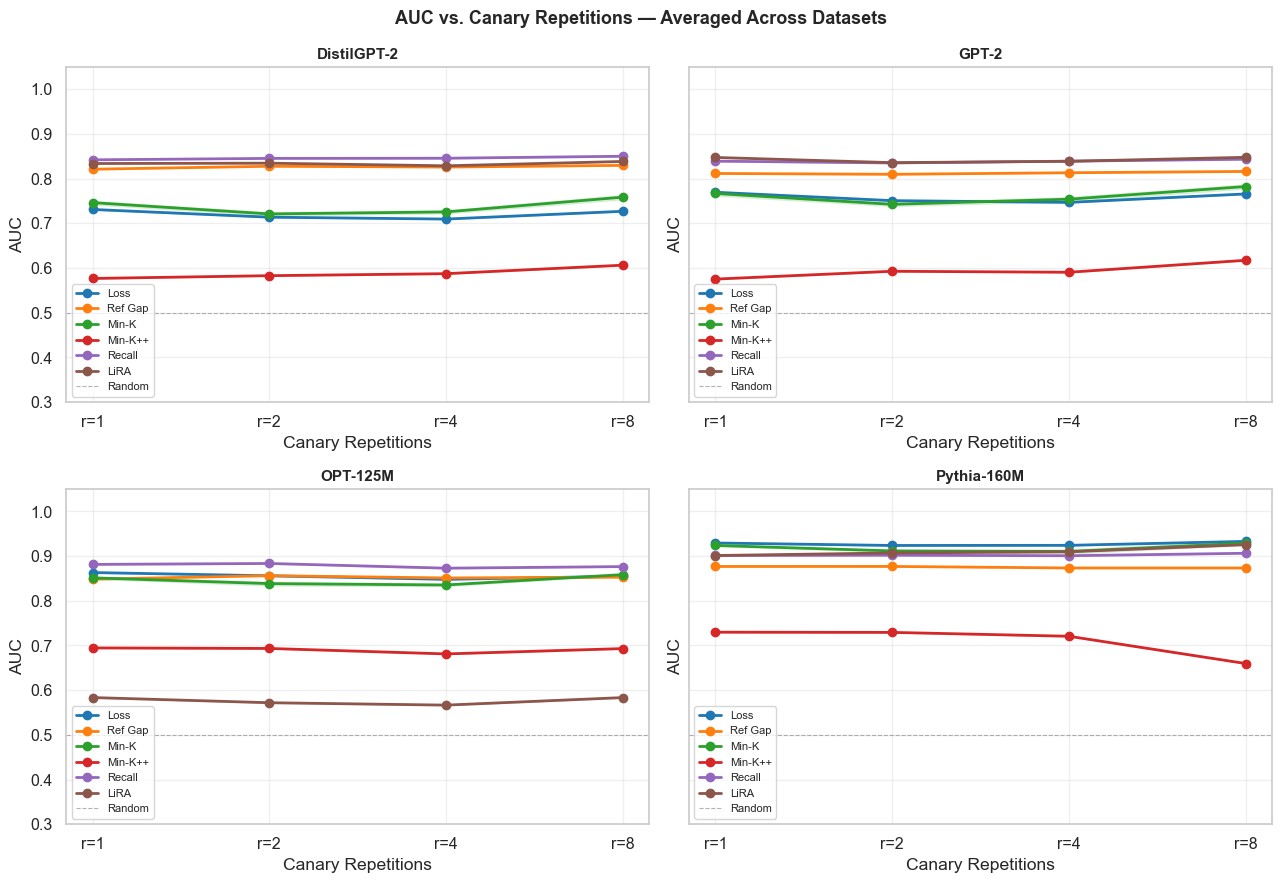

In [19]:
# ── AUC vs repetition ────────────────────────────────────────────────────────
print("### AUC vs. Canary Repetitions — per attack, per model\n")

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)

for ax, model in zip(axes.flatten(), MODELS_ORDER):
    sub = metrics_df[metrics_df["model_short"] == model]
    for attack in ATTACK_LABELS:
        d = (sub[sub["attack"] == attack]
             .groupby("canary_rep")[["auc","auc_std"]]
             .mean()
             .reset_index()
             .sort_values("canary_rep"))
        if d.empty:
            continue
        ax.plot(d["canary_rep"], d["auc"],
                marker="o", lw=2, color=ATTACK_COLORS[attack],
                label=ATTACK_LABELS[attack])
        ax.fill_between(d["canary_rep"],
                         d["auc"] - d["auc_std"],
                         d["auc"] + d["auc_std"],
                         alpha=0.12, color=ATTACK_COLORS[attack])

    ax.axhline(0.5, color="grey", lw=0.8, ls="--", alpha=0.6, label="Random")
    ax.set_xscale("log", base=2)
    ax.set_xticks([1,2,4,8]); ax.set_xticklabels(["r=1","r=2","r=4","r=8"])
    ax.set_xlabel("Canary Repetitions")
    ax.set_ylabel("AUC")
    ax.set_ylim(0.3, 1.05)
    ax.set_title(MODEL_LABELS.get(model, model), fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

fig.suptitle("AUC vs. Canary Repetitions — Averaged Across Datasets",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### How do canary scores shift as repetitions increase?



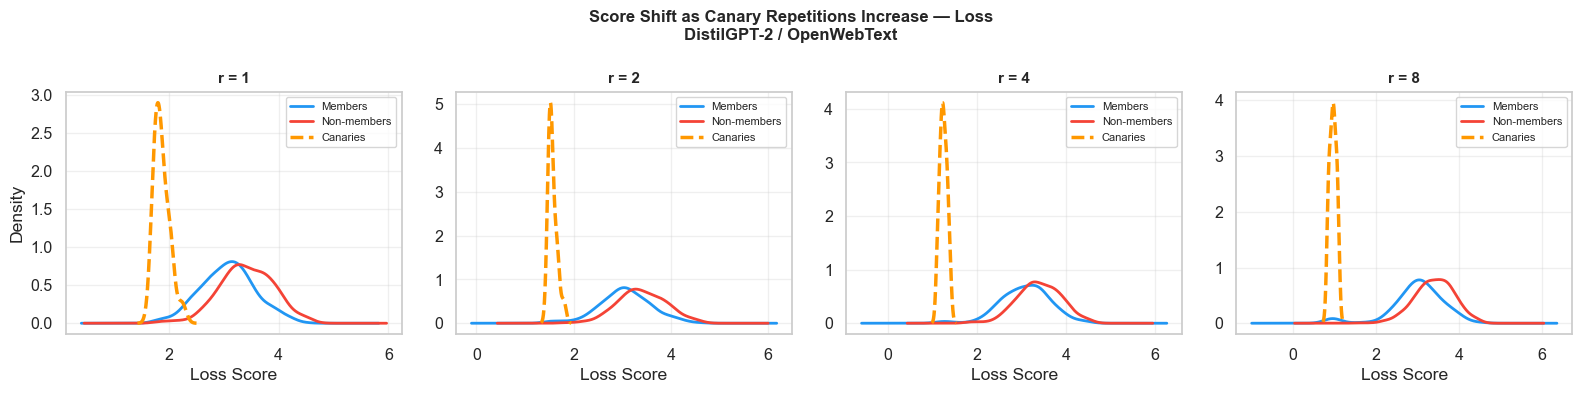

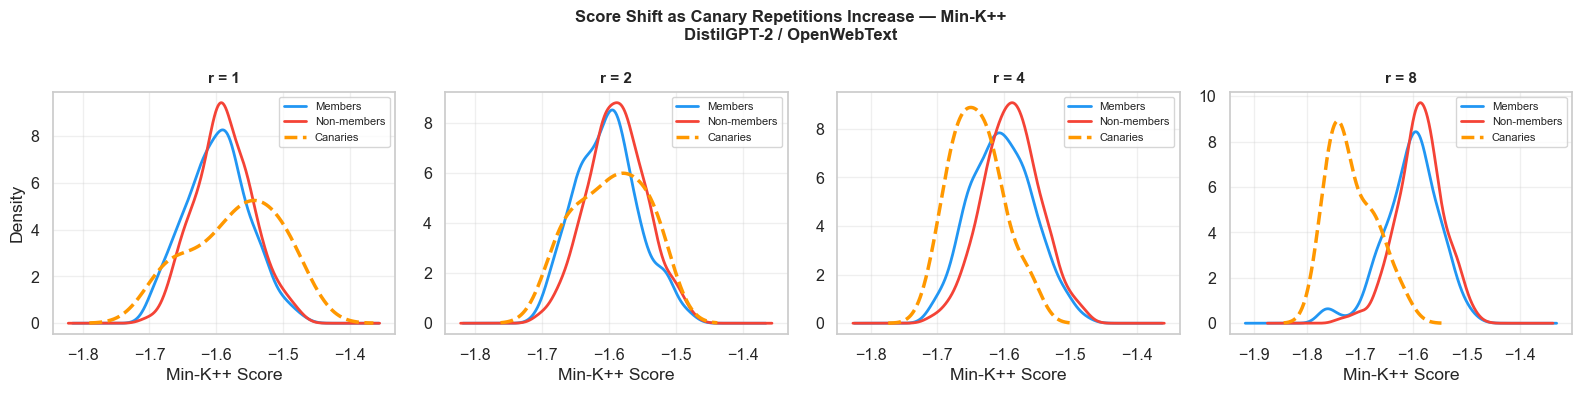

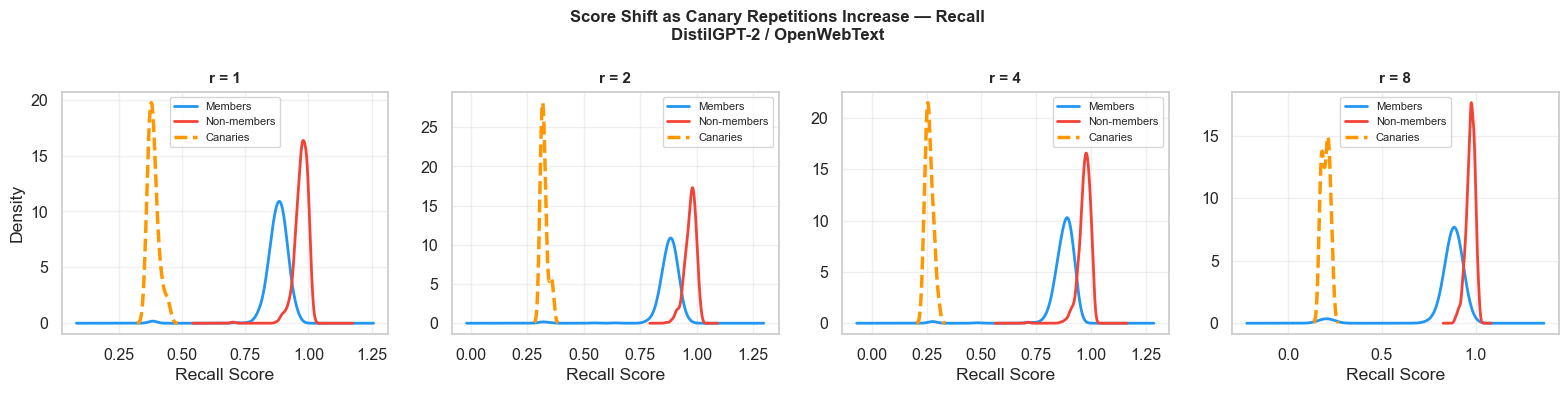

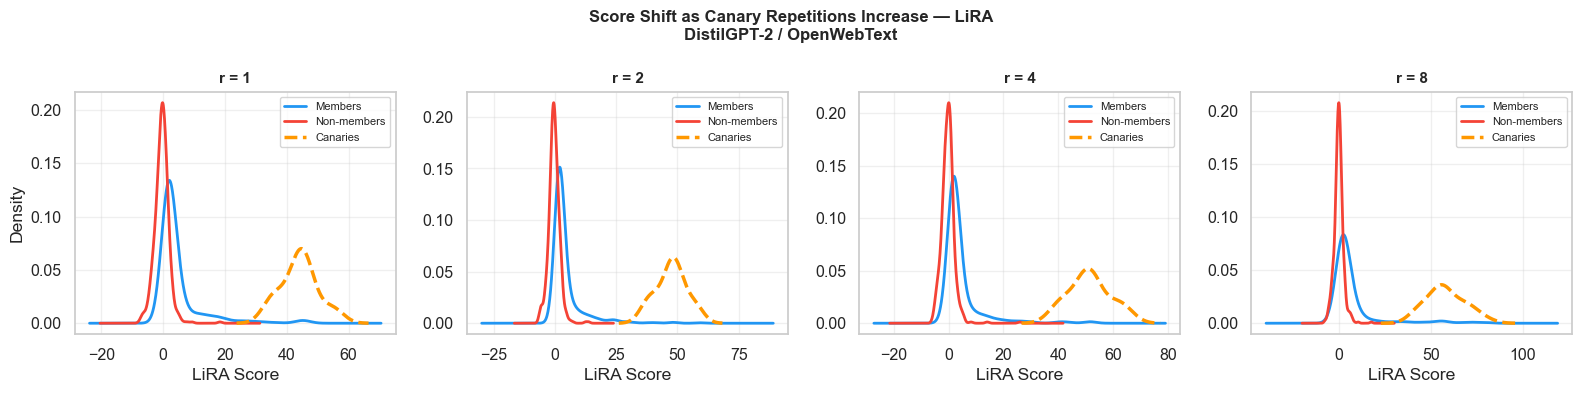


→ Watch how the canary KDE shifts leftward (lower score) as r increases.
  This is the model 'memorising' the canary text.


In [20]:
# ── Score shift with repetitions for canaries ────────────────────────────────
print("### How do canary scores shift as repetitions increase?\n")

def plot_score_shift(model, dataset, attack):
    attack_label = ATTACK_LABELS.get(attack, attack)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

    for ax, rep in zip(axes, [1, 2, 4, 8]):
        sub = scores_df[
            (scores_df["model_clean"] == model) &
            (scores_df["dataset_clean"] == dataset) &
            (scores_df["attack"] == attack) &
            (scores_df["canary_rep_int"] == rep)
        ]
        if sub.empty:
            ax.set_visible(False)
            continue
        d = sub.groupby(["sample_id","source"])["score"].mean().reset_index()
        lo, hi = d["score"].quantile(0.01), d["score"].quantile(0.99)
        d = d[(d["score"] >= lo) & (d["score"] <= hi)]

        for src, color, lw, ls in [
            ("train",  "#2196F3", 2,   "-"),
            ("test",   "#F44336", 2,   "-"),
            ("canary", "#FF9800", 2.5, "--"),
        ]:
            s = d[d["source"] == src]["score"]
            if len(s) >= 5:
                s.plot.kde(ax=ax, color=color, lw=lw, ls=ls,
                        label={"train":"Members","test":"Non-members","canary":"Canaries"}[src])
        ax.set_title(f"r = {rep}", fontsize=11, fontweight="bold")
        ax.set_xlabel(f"{attack_label} Score")
        ax.set_ylabel("Density" if rep == 1 else "")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    fig.suptitle(f"Score Shift as Canary Repetitions Increase — {attack_label}\n"
                f"{MODEL_LABELS.get(model, model)} / {DATASET_LABELS.get(dataset, dataset)}",
                fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_score_shift("distilgpt2", "openwebtext", "loss")
plot_score_shift("distilgpt2", "openwebtext", "min_k_pp")
plot_score_shift("distilgpt2", "openwebtext", "recall")
plot_score_shift("distilgpt2", "openwebtext", "lira")

print("\n→ Watch how the canary KDE shifts leftward (lower score) as r increases.")
print("  This is the model 'memorising' the canary text.")


### TPR @ 1% FPR vs. Repetitions — the operational privacy risk curve



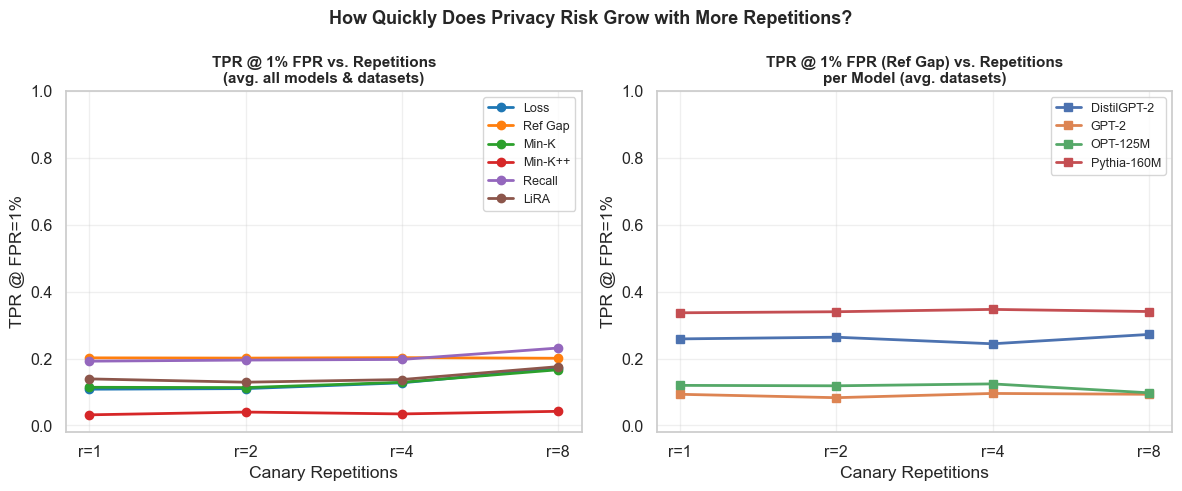

In [21]:
# ── TPR @ low FPR vs repetition — the privacy-critical view ──────────────────
print("### TPR @ 1% FPR vs. Repetitions — the operational privacy risk curve\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: across datasets (averaged over models)
ax = axes[0]
for attack in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]:
    d = (metrics_df[metrics_df["attack"] == attack]
         .groupby("canary_rep")["tpr@fpr=0.01"]
         .mean()
         .reset_index()
         .sort_values("canary_rep"))
    if d.empty: continue
    ax.plot(d["canary_rep"], d["tpr@fpr=0.01"],
            marker="o", lw=2, color=ATTACK_COLORS[attack],
            label=ATTACK_LABELS[attack])
ax.set_xscale("log", base=2)
ax.set_xticks([1,2,4,8]); ax.set_xticklabels(["r=1","r=2","r=4","r=8"])
ax.set_xlabel("Canary Repetitions"); ax.set_ylabel("TPR @ FPR=1%")
ax.set_ylim(-0.02, 1.0)
ax.set_title("TPR @ 1% FPR vs. Repetitions\n(avg. all models & datasets)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Right: across models (averaged over datasets)
ax = axes[1]
for model in MODELS_ORDER:
    sub = metrics_df[metrics_df["model_short"] == model]
    for attack in ["ref_gap"]:  # best attack for clarity
        d = (sub[sub["attack"] == attack]
             .groupby("canary_rep")["tpr@fpr=0.01"]
             .mean()
             .reset_index()
             .sort_values("canary_rep"))
        if d.empty: continue
        ax.plot(d["canary_rep"], d["tpr@fpr=0.01"],
                marker="s", lw=2, label=MODEL_LABELS.get(model, model))
ax.set_xscale("log", base=2)
ax.set_xticks([1,2,4,8]); ax.set_xticklabels(["r=1","r=2","r=4","r=8"])
ax.set_xlabel("Canary Repetitions"); ax.set_ylabel("TPR @ FPR=1%")
ax.set_ylim(-0.02, 1.0)
ax.set_title("TPR @ 1% FPR (Ref Gap) vs. Repetitions\nper Model (avg. datasets)",
             fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

fig.suptitle("How Quickly Does Privacy Risk Grow with More Repetitions?",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 8. Attack × Dataset × Model Interactions

Where does each attack *work* and where does it *fail*? A systematic breakdown of which (attack, model, dataset, repetition) combinations give meaningful MIA results.

### AUC heatmap per canary repetition — attack × (model, dataset) combined



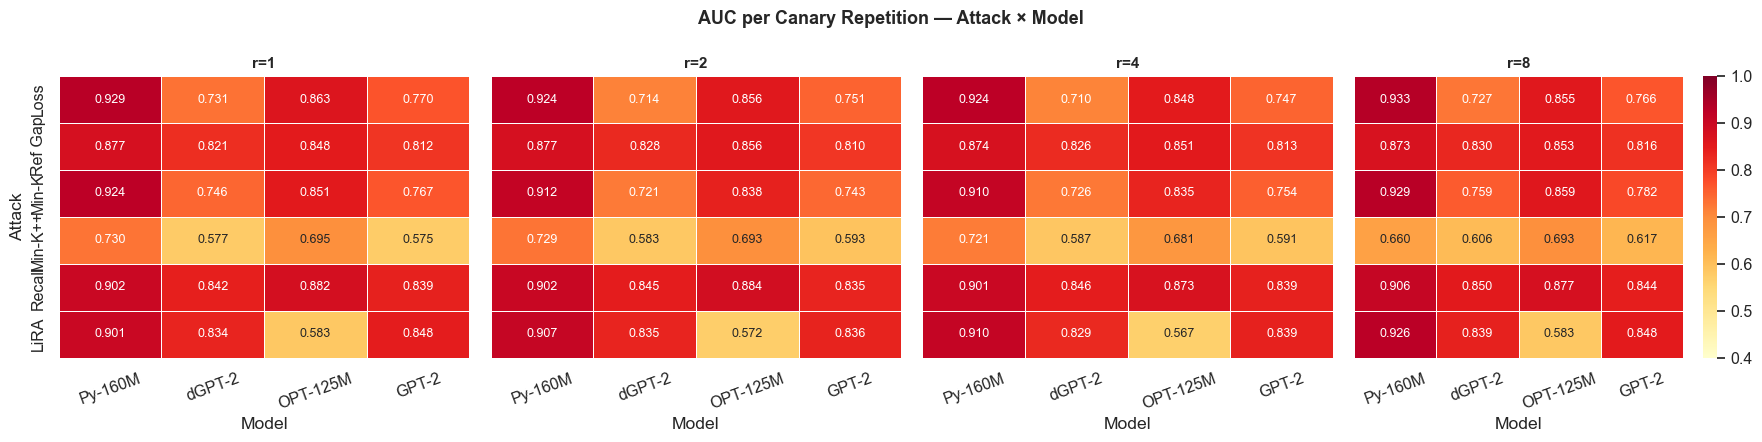

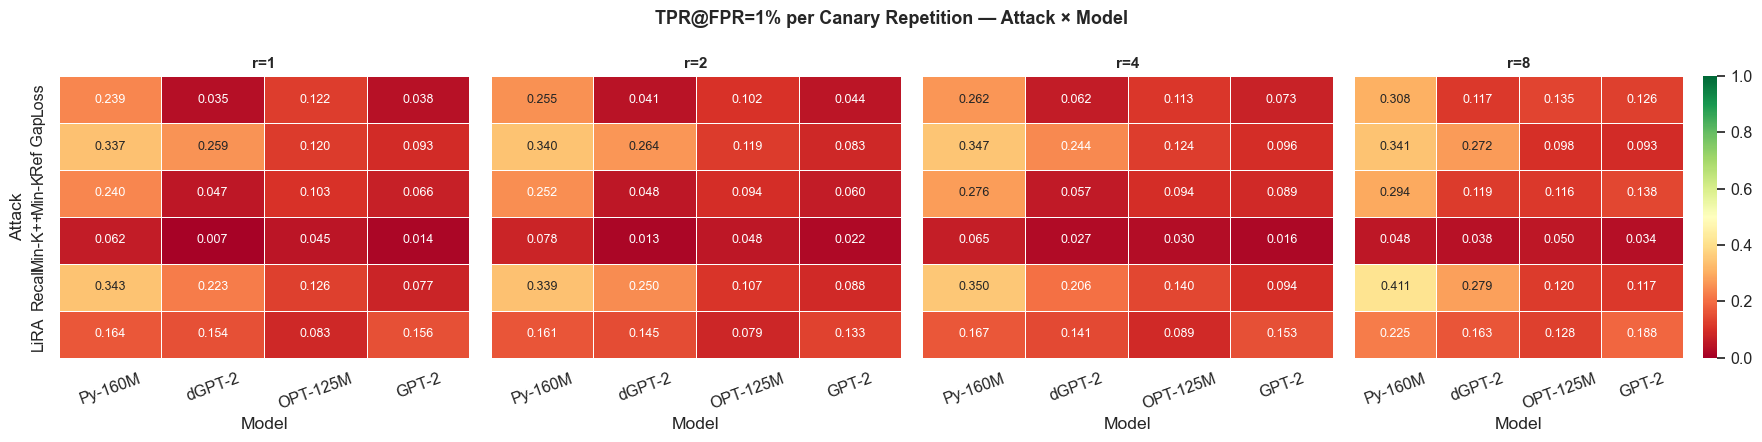

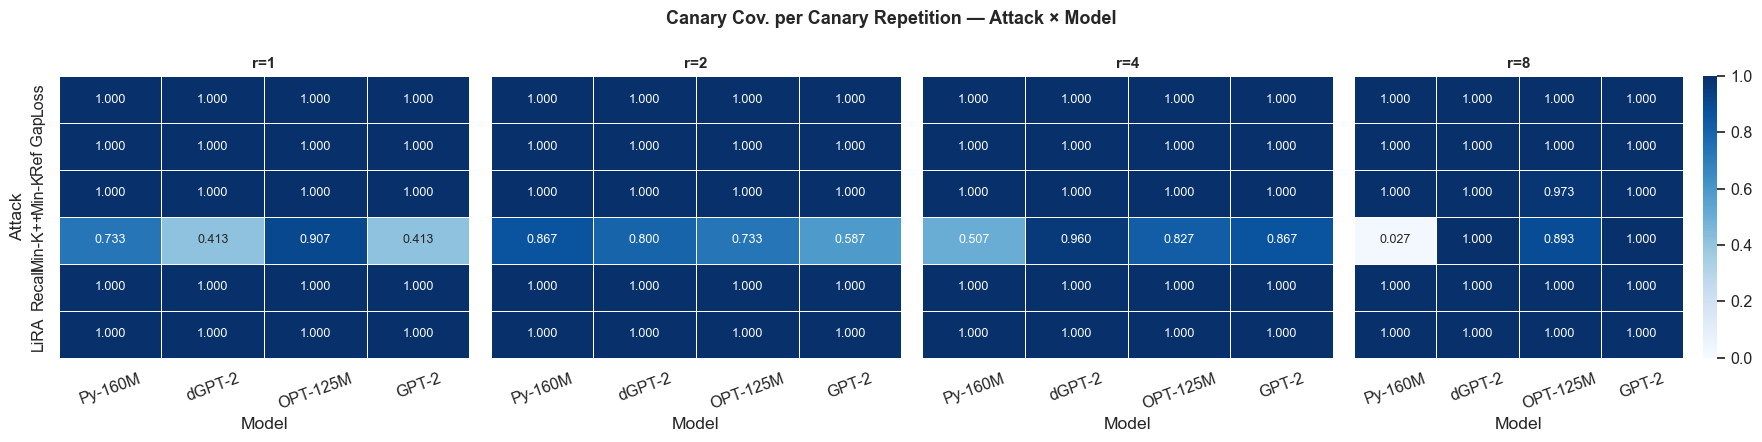

In [22]:
# ── Multi-metric heatmaps per canary rep ─────────────────────────────────────
print("### AUC heatmap per canary repetition — attack × (model, dataset) combined\n")

metrics_to_show = [
    ("auc",           "AUC",           "YlOrRd", 0.4, 1.0),
    ("tpr@fpr=0.01",  "TPR@FPR=1%",    "RdYlGn", 0.0, 1.0),
    ("coverage_canaries", "Canary Cov.", "Blues", 0.0, 1.0),
]

for metric, label, cmap, vmin, vmax in metrics_to_show:
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)
    for ax, rep in zip(axes, [1, 2, 4, 8]):
        sub = metrics_df[metrics_df["canary_rep"] == rep]
        pivot = (sub.groupby(["attack","model_short"])[metric]
                 .mean().unstack("model_short"))
        attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.index]
        pivot = pivot.loc[attack_order]
        pivot.index = [ATTACK_LABELS.get(a,a) for a in pivot.index]
        pivot.columns = [MODEL_LABELS.get(c,c).replace("Pythia-","Py-").replace("DistilGPT","dGPT")
                         for c in pivot.columns]
        sns.heatmap(pivot, annot=True, fmt=".3f", cmap=cmap, vmin=vmin, vmax=vmax,
                    ax=ax, linewidths=0.5, annot_kws={"size": 9},
                    cbar=(ax == axes[-1]))
        ax.set_title(f"r={rep}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Model")
        ax.set_ylabel("Attack" if rep == 1 else "")
        ax.tick_params(axis="x", rotation=20)

    fig.suptitle(f"{label} per Canary Repetition — Attack × Model",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


### Attack effectiveness map — where each attack works (AUC > 0.7 = effective)



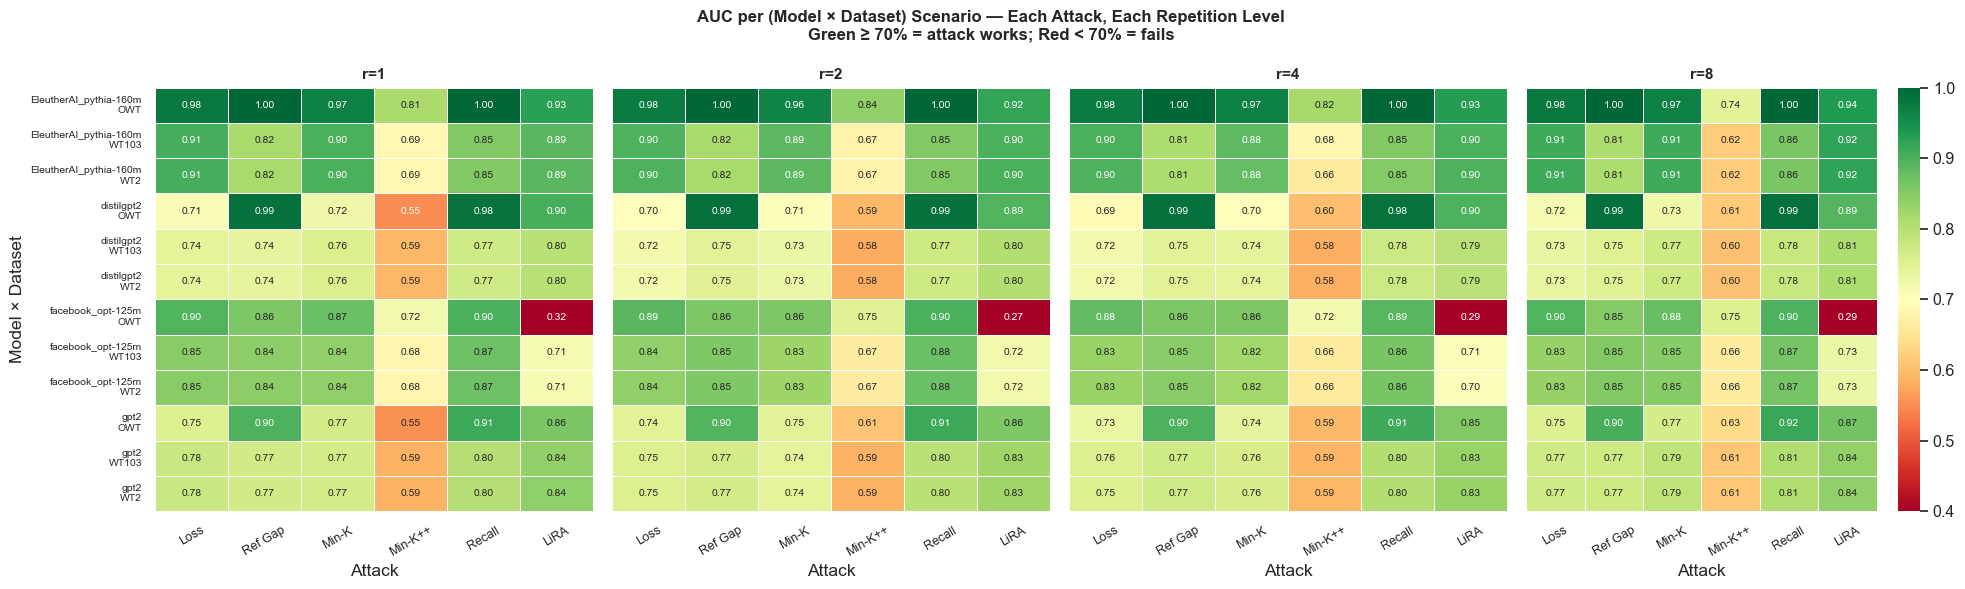

In [23]:
# ── "Works / Doesn't Work" binary maps — attack × scenario ───────────────────
print("### Attack effectiveness map — where each attack works (AUC > 0.7 = effective)\n")

THRESHOLD_EFFECTIVE = 0.70  # AUC > 0.70 = meaningful detection

effectiveness = []
for (attack, model, dataset, rep), grp in metrics_df.groupby(["attack","model_short","dataset","canary_rep"]):
    auc = grp["auc"].mean()
    tpr1 = grp["tpr@fpr=0.01"].mean()
    effectiveness.append({
        "attack": attack, "model": model, "dataset": dataset,
        "canary_rep": rep, "auc": auc, "tpr@fpr=0.01": tpr1,
        "works": int(auc >= THRESHOLD_EFFECTIVE),
    })
eff_df = pd.DataFrame(effectiveness)

# Heatmap: scenario = "{model}×{dataset}" vs attack, at each rep level
fig, axes = plt.subplots(1, 4, figsize=(20, 6), sharey=True)
for ax, rep in zip(axes, [1, 2, 4, 8]):
    sub = eff_df[eff_df["canary_rep"] == rep].copy()
    sub["scenario"] = sub["model"] + "\n" + sub["dataset"].map(
        {"openwebtext":"OWT","wikitext-2-raw-v1":"WT2","wikitext-103-raw-v1":"WT103"})
    pivot = sub.pivot_table(index="scenario", columns="attack", values="auc", aggfunc="mean")
    attack_order = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"] if a in pivot.columns]
    pivot = pivot[attack_order]
    pivot.columns = [ATTACK_LABELS.get(a,a) for a in pivot.columns]

    # Use a diverging cmap centred at 0.5 (chance)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0.4, vmax=1.0,
                ax=ax, linewidths=0.4, annot_kws={"size": 7.5},
                cbar=(ax == axes[-1]))
    ax.set_title(f"r={rep}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Attack")
    ax.set_ylabel("Model × Dataset" if rep == 1 else "")
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", labelsize=7.5)

fig.suptitle(f"AUC per (Model × Dataset) Scenario — Each Attack, Each Repetition Level\n"
             f"Green ≥ {THRESHOLD_EFFECTIVE:.0%} = attack works; Red < {THRESHOLD_EFFECTIVE:.0%} = fails",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


### Interaction: Does dataset or model dominate attack performance?



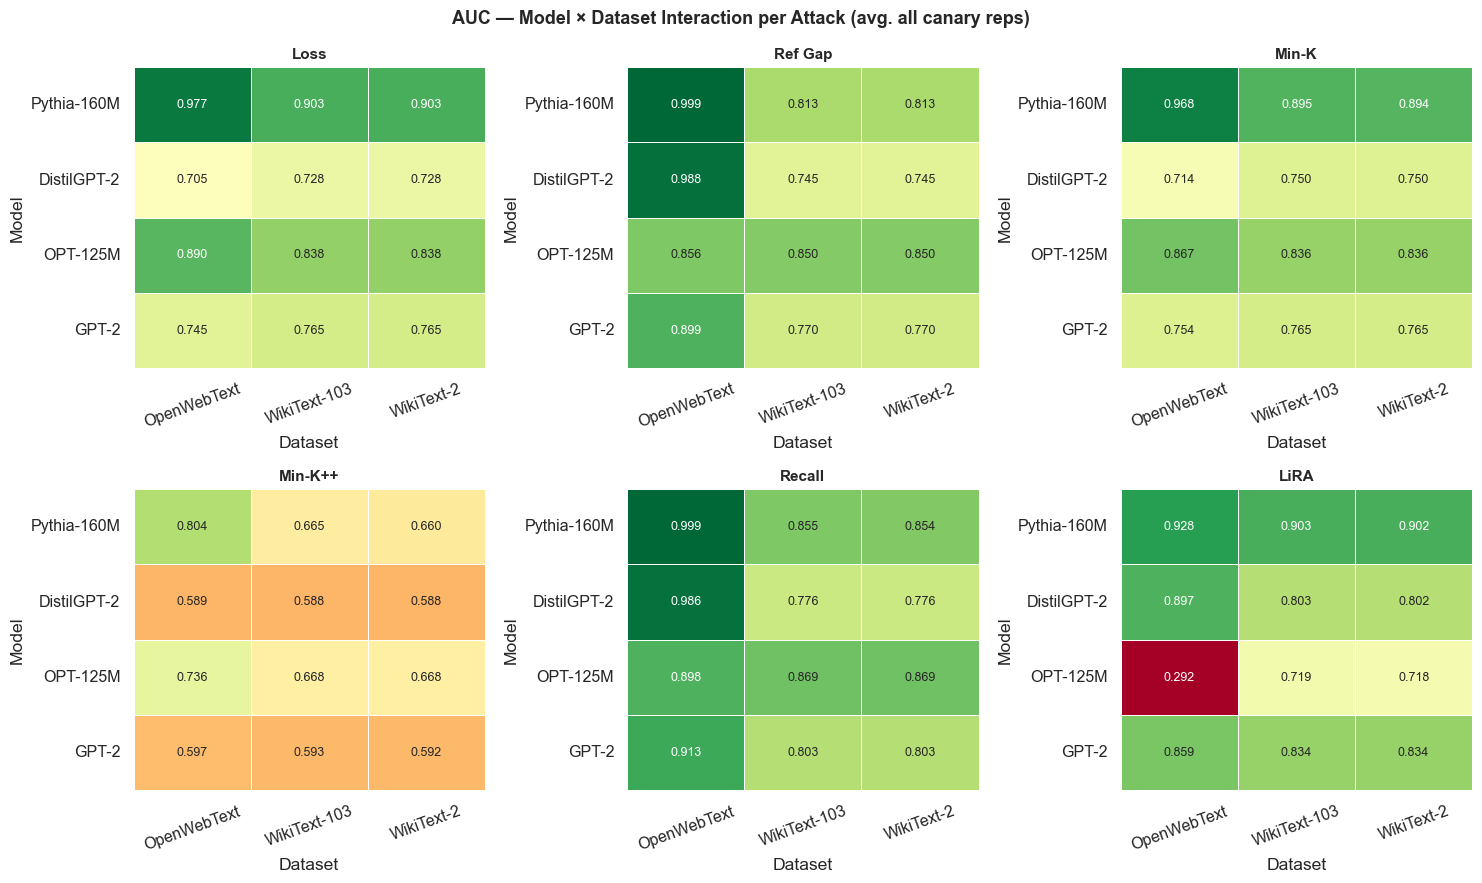

In [24]:
# ── Model vs Dataset interaction: does dataset matter more than model? ────────
print("### Interaction: Does dataset or model dominate attack performance?\n")

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
attacks_order = ["loss","ref_gap","min_k","min_k_pp","recall","lira"]

for ax, attack in zip(axes.flatten(), attacks_order):
    sub = metrics_df[metrics_df["attack"] == attack]
    pivot = (sub.groupby(["model_short","dataset"])["auc"]
             .mean().unstack("dataset"))
    pivot.index = [MODEL_LABELS.get(m,m) for m in pivot.index]
    pivot.columns = [DATASET_LABELS.get(c,c) for c in pivot.columns]

    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.4, vmax=1.0,
                ax=ax, linewidths=0.5, annot_kws={"size": 9},
                cbar=False)
    ax.set_title(f"{ATTACK_LABELS.get(attack,attack)}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Model")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("AUC — Model × Dataset Interaction per Attack (avg. all canary reps)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Precision–Recall Trade-offs

AUC summarises the ROC curve but the PR curve is more informative when class imbalance exists. This section compares attacks via PR curves and the F1 gap between threshold choices.

### Precision–Recall Curves — r=1, all models × OpenWebText


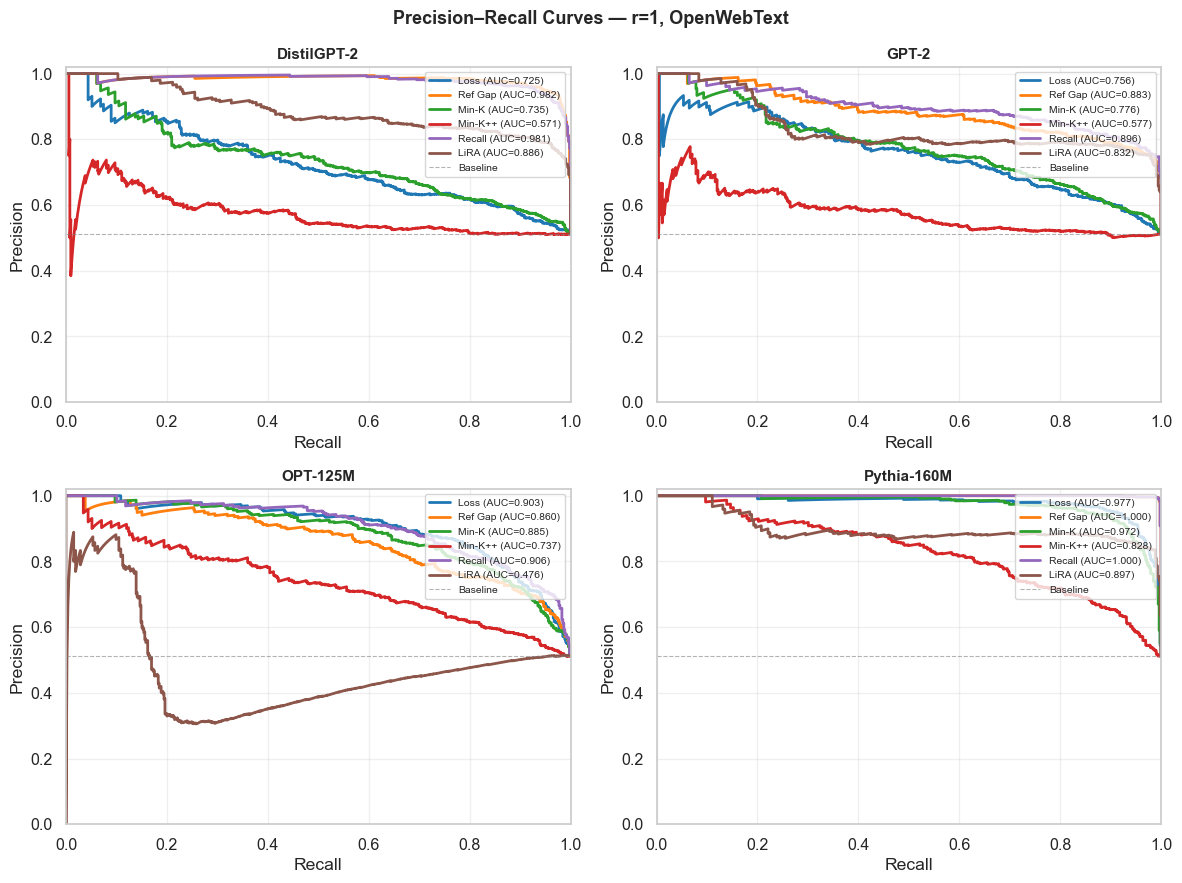

In [25]:
def compute_pr_from_scores(df_subset, attack):
    """Compute precision-recall curve from score rows for a single attack."""
    d = df_subset[df_subset["attack"] == attack].copy()
    if len(d) < 10:
        return None, None, None
    d = d.groupby(["sample_id","label"])["score"].mean().reset_index()
    labels = d["label"].values
    scores = d["score"].values
    if len(set(labels)) < 2:
        return None, None, None
    smaller = ATTACK_SMALLER_IS_MEMBER.get(attack, True)
    s = -scores if smaller else scores
    try:
        precision, recall, _ = precision_recall_curve(labels, s)
        pr_auc = sklearn_auc(recall, precision)
        return precision, recall, pr_auc
    except Exception:
        return None, None, None


# ── PR Curves — per model, per dataset ────────────────────────────────────────
print("### Precision–Recall Curves — r=1, all models × OpenWebText")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, model in zip(axes.flatten(), MODELS_ORDER):
    sub = scores_df[
        (scores_df["model_full"] == model) &
        (scores_df["dataset_clean"] == "openwebtext") &
        (scores_df["canary_rep_int"] == 1)
    ]
    for attack in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]:
        if "attack" not in sub.columns or attack not in sub["attack"].unique():
            continue
        prec, rec, pr_auc = compute_pr_from_scores(sub, attack)
        if prec is None:
            continue
        ax.plot(rec, prec, color=ATTACK_COLORS[attack], lw=2,
                label=f"{ATTACK_LABELS[attack]} (AUC={pr_auc:.3f})")
    # Baseline (fraction of positives)
    baseline = (sub["label"] == 1).mean() if not sub.empty and "label" in sub.columns else 0.5
    ax.axhline(baseline, color="grey", lw=0.8, ls="--", alpha=0.6, label="Baseline")
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(MODEL_LABELS.get(model, model), fontsize=11, fontweight="bold")
    ax.legend(fontsize=7.5, loc="upper right")
    ax.grid(alpha=0.3)

fig.suptitle("Precision–Recall Curves — r=1, OpenWebText",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### F1 Gap — median threshold vs optimally tuned threshold

Large gap = attack needs careful threshold tuning to reach its potential.



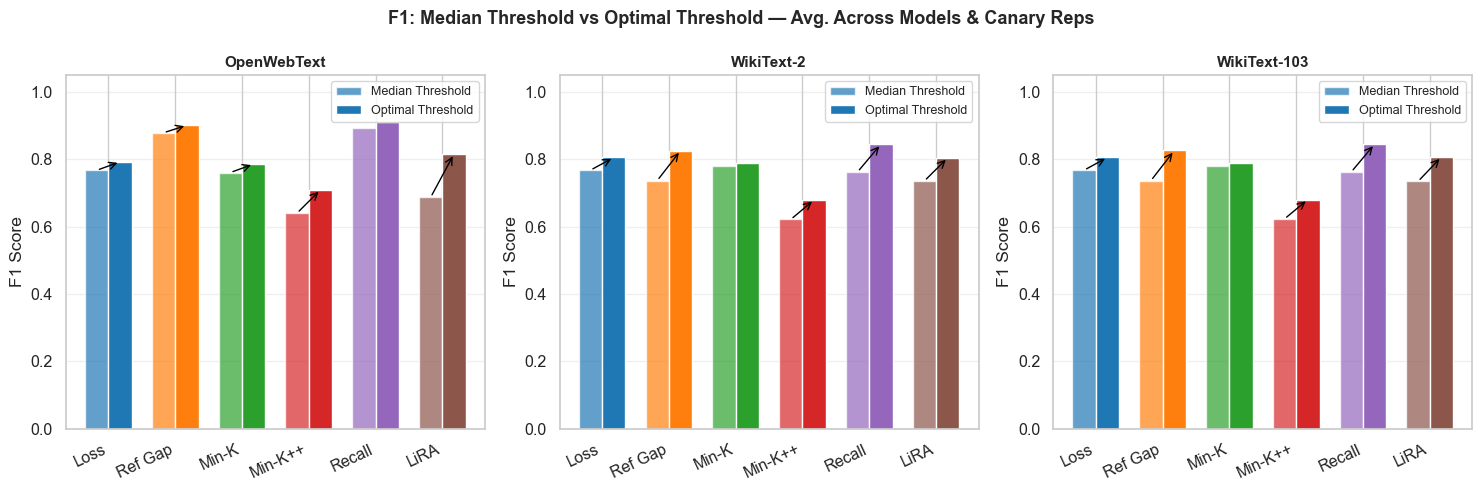


→ If optimal >> median, the attack score has good discriminative power
  but the default threshold (median) is a poor operating point.


In [26]:
# ── F1 gap: median threshold vs best-F1 threshold ────────────────────────────
print("### F1 Gap — median threshold vs optimally tuned threshold\n")
print("Large gap = attack needs careful threshold tuning to reach its potential.\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, dataset in zip(axes, ["openwebtext","wikitext-2-raw-v1","wikitext-103-raw-v1"]):
    sub = metrics_df[metrics_df["dataset"] == dataset]
    attacks_order = ["loss","ref_gap","min_k","min_k_pp","recall","lira"]
    f1_med = [sub[sub["attack"]==a]["f1_median"].mean() for a in attacks_order]
    f1_opt = [sub[sub["attack"]==a]["f1_f1"].mean()    for a in attacks_order]
    labels  = [ATTACK_LABELS.get(a,a) for a in attacks_order]

    x = np.arange(len(attacks_order))
    w = 0.35
    b1 = ax.bar(x - w/2, f1_med, w, label="Median Threshold", 
                color=[ATTACK_COLORS[a] for a in attacks_order], alpha=0.7)
    b2 = ax.bar(x + w/2, f1_opt, w, label="Optimal Threshold",
                color=[ATTACK_COLORS[a] for a in attacks_order], alpha=1.0)
    # Draw gap arrows
    for xi, fm, fo in zip(x, f1_med, f1_opt):
        if abs(fo - fm) > 0.02:
            ax.annotate("", xy=(xi + w/2, fo), xytext=(xi - w/2, fm),
                        arrowprops=dict(arrowstyle="->", color="black", lw=1))

    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 Score")
    ax.set_title(DATASET_LABELS.get(dataset, dataset), fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("F1: Median Threshold vs Optimal Threshold — Avg. Across Models & Canary Reps",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n→ If optimal >> median, the attack score has good discriminative power")
print("  but the default threshold (median) is a poor operating point.")


### Precision vs. Recall scatter — what tradeoff does each attack make?



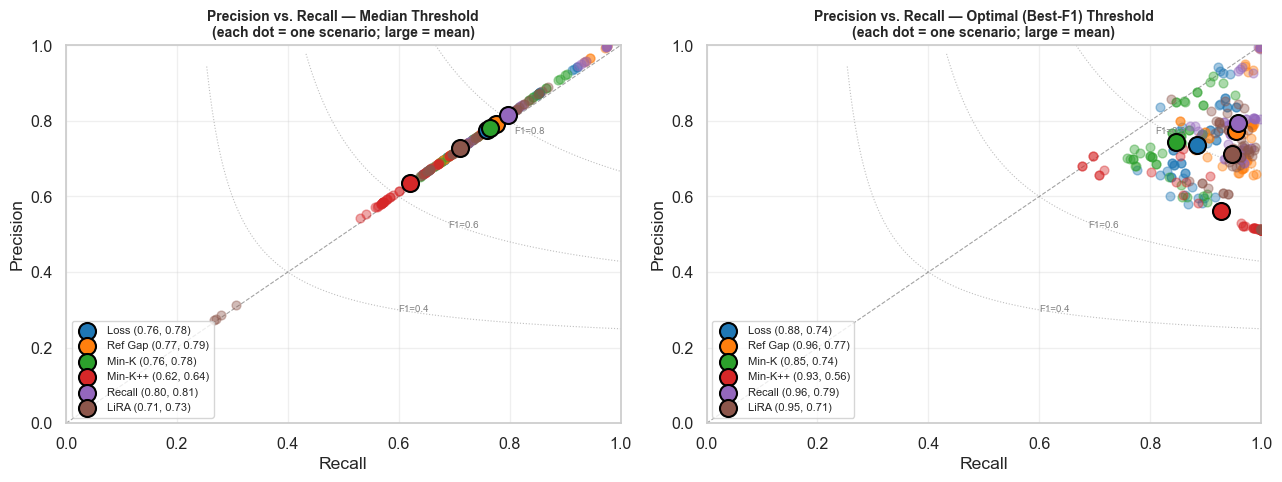

In [27]:
# ── Precision vs Recall scatter — attack family fingerprints ─────────────────
print("### Precision vs. Recall scatter — what tradeoff does each attack make?\n")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, threshold_type, label in zip(axes,
        ["_median", "_f1"], ["Median Threshold", "Optimal (Best-F1) Threshold"]):
    prec_col = f"precision{threshold_type}"
    rec_col  = f"recall{threshold_type}"
    
    for attack in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]:
        sub = metrics_df[metrics_df["attack"] == attack]
        ps = sub[prec_col].dropna()
        rs = sub[rec_col].dropna()
        if ps.empty:
            continue
        ax.scatter(rs, ps, color=ATTACK_COLORS[attack], s=40, alpha=0.4, zorder=3)
        ax.scatter(rs.mean(), ps.mean(), color=ATTACK_COLORS[attack], s=150,
                   edgecolor="black", lw=1.5, zorder=5,
                   label=f"{ATTACK_LABELS[attack]} ({rs.mean():.2f}, {ps.mean():.2f})")

    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.plot([0,1],[0,1],"k--", lw=0.8, alpha=0.4)
    # Iso-F1 lines
    for f1_level in [0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1.0, 200)
        p_vals = f1_level * r_vals / (2 * r_vals - f1_level)
        mask = (p_vals >= 0) & (p_vals <= 1)
        ax.plot(r_vals[mask], p_vals[mask], ":", color="grey", lw=0.8, alpha=0.5)
        idx = len(r_vals[mask]) // 2
        ax.text(r_vals[mask][idx], p_vals[mask][idx], f"F1={f1_level}",
                fontsize=7, color="grey", ha="center")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"Precision vs. Recall — {label}\n(each dot = one scenario; large = mean)",
                 fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Sample Vulnerability Analysis

Why are some samples detected and others not? This section correlates per-sample text features (length, token rarity, word frequency, loss gap) with MIA detection success.

In [28]:
# ── Load sample_analysis.csv files ────────────────────────────────────────────
sample_dfs = []
for folder in sorted(OUTPUT_DIR.iterdir()):
    if not folder.is_dir():
        continue
    model, dataset, rep = parse_folder_name(folder.name)
    if rep is None:
        continue
    p = folder / "sample_analysis.csv"
    if p.exists():
        try:
            df = pd.read_csv(p)
            df["model_clean"]    = model.split("/")[-1]
            df["model_full"]     = model
            df["dataset_clean"]  = dataset
            df["canary_rep_int"] = rep
            sample_dfs.append(df)
        except Exception as e:
            print(f"  ⚠  {p}: {e}")

sample_df = pd.concat(sample_dfs, ignore_index=True) if sample_dfs else pd.DataFrame()
print(f"Loaded {len(sample_df):,} sample analysis rows.")
if not sample_df.empty:
    print("Columns:", list(sample_df.columns))
    print("Sources:", sample_df["source"].value_counts().to_dict())


Loaded 295,200 sample analysis rows.
Columns: ['sample_id', 'label', 'source', 'attack', 'score', 'prediction', 'correct', 'text_length', 'token_rarity', 'word_frequency', 'target_loss', 'ref_loss', 'loss_diff', 'model', 'dataset', 'canary_rep', 'model_clean', 'model_full', 'dataset_clean', 'canary_rep_int']
Sources: {'test': 144000, 'train': 144000, 'canary': 7200}


### Feature profiles — correct vs wrong MIA predictions on members



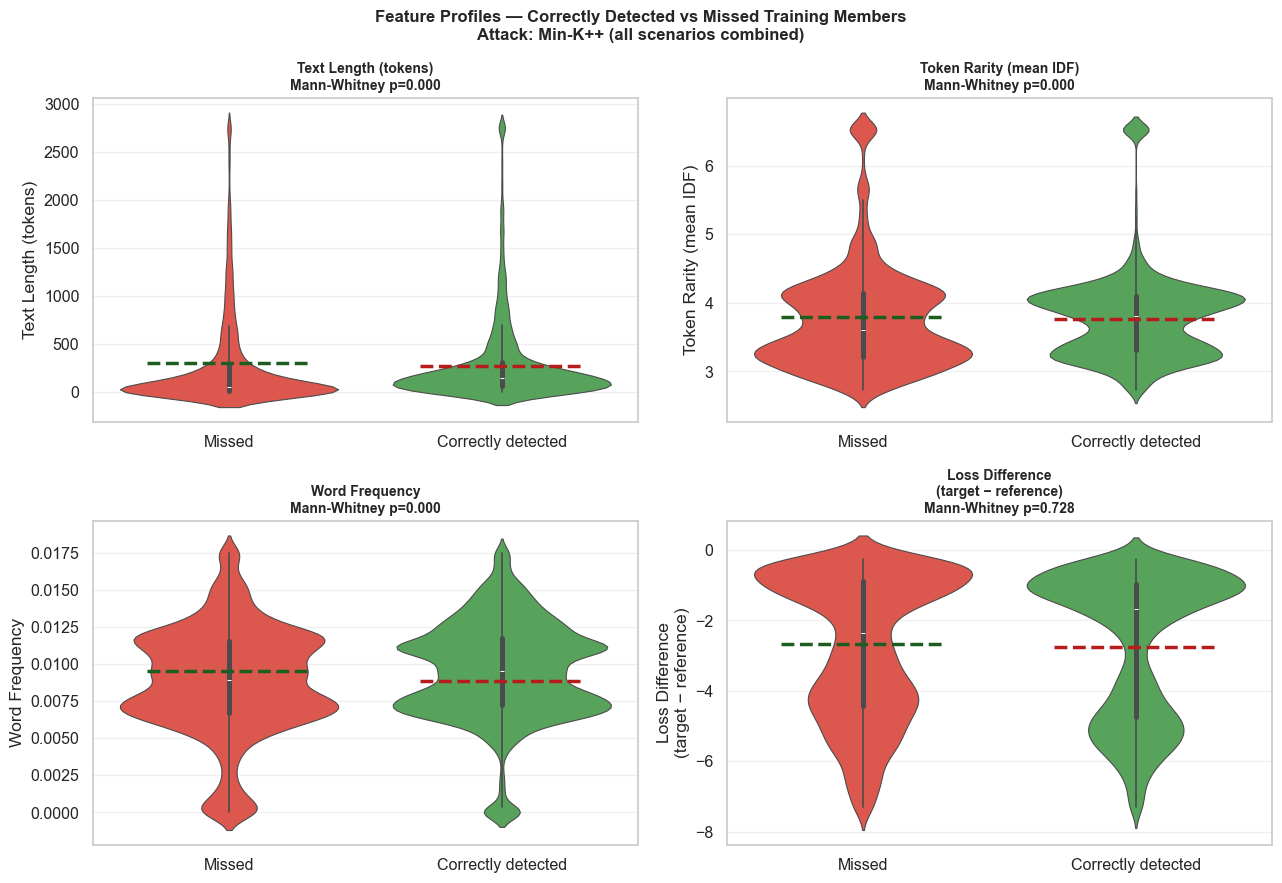

→ Features with significant p-values (< 0.05) differentiate detectable samples.


In [29]:
# ── Feature distributions: correctly classified vs misclassified members ──────
print("### Feature profiles — correct vs wrong MIA predictions on members\n")

if not sample_df.empty:
    features = ["text_length", "token_rarity", "word_frequency", "loss_diff"]
    feat_labels = {
        "text_length":    "Text Length (tokens)",
        "token_rarity":   "Token Rarity (mean IDF)",
        "word_frequency": "Word Frequency",
        "loss_diff":      "Loss Difference\n(target − reference)",
    }

    # Focus on member samples only; pick one representative attack that has rich data
    ref_attack = "min_k_pp" if "min_k_pp" in sample_df.get("attack", pd.Series()).unique() else \
                 sample_df["attack"].iloc[0] if not sample_df.empty else "loss"

    sub = sample_df[
        (sample_df["source"] == "train") &
        (sample_df["attack"] == ref_attack)
    ].copy()

    if not sub.empty and "correct" in sub.columns:
        sub["classification"] = sub["correct"].map({1: "Correctly detected", 0: "Missed"})

        fig, axes = plt.subplots(2, 2, figsize=(13, 9))
        for ax, feat in zip(axes.flatten(), features):
            if feat not in sub.columns:
                ax.set_visible(False)
                continue
            d = sub[[feat, "classification"]].dropna()
            d[feat] = d[feat].clip(d[feat].quantile(0.01), d[feat].quantile(0.99))
            sns.violinplot(data=d, x="classification", y=feat,
                           palette={"Correctly detected": "#4CAF50", "Missed": "#F44336"},
                           inner="box", ax=ax, linewidth=0.8)
            # Overlay means
            for cat, color in [("Correctly detected","#1B5E20"),("Missed","#B71C1C")]:
                mean_val = d[d["classification"]==cat][feat].mean()
                ax.axhline(mean_val, xmin=0.1 if cat=="Correctly detected" else 0.6,
                           xmax=0.4 if cat=="Correctly detected" else 0.9,
                           color=color, lw=2.5, ls="--")
            ax.set_xlabel(""); ax.set_ylabel(feat_labels.get(feat, feat))
            # Mann-Whitney U test
            a = d[d["classification"]=="Correctly detected"][feat].dropna()
            b = d[d["classification"]=="Missed"][feat].dropna()
            if len(a) >= 5 and len(b) >= 5:
                stat, p = scipy_stats.mannwhitneyu(a, b, alternative="two-sided")
                ax.set_title(f"{feat_labels.get(feat,feat)}\nMann-Whitney p={p:.3f}",
                             fontsize=10, fontweight="bold")
            else:
                ax.set_title(feat_labels.get(feat, feat), fontsize=10, fontweight="bold")
            ax.grid(axis="y", alpha=0.3)

        fig.suptitle(f"Feature Profiles — Correctly Detected vs Missed Training Members\n"
                     f"Attack: {ATTACK_LABELS.get(ref_attack, ref_attack)} (all scenarios combined)",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()
        print("→ Features with significant p-values (< 0.05) differentiate detectable samples.")


### Correlation heatmap — sample features vs attack scores



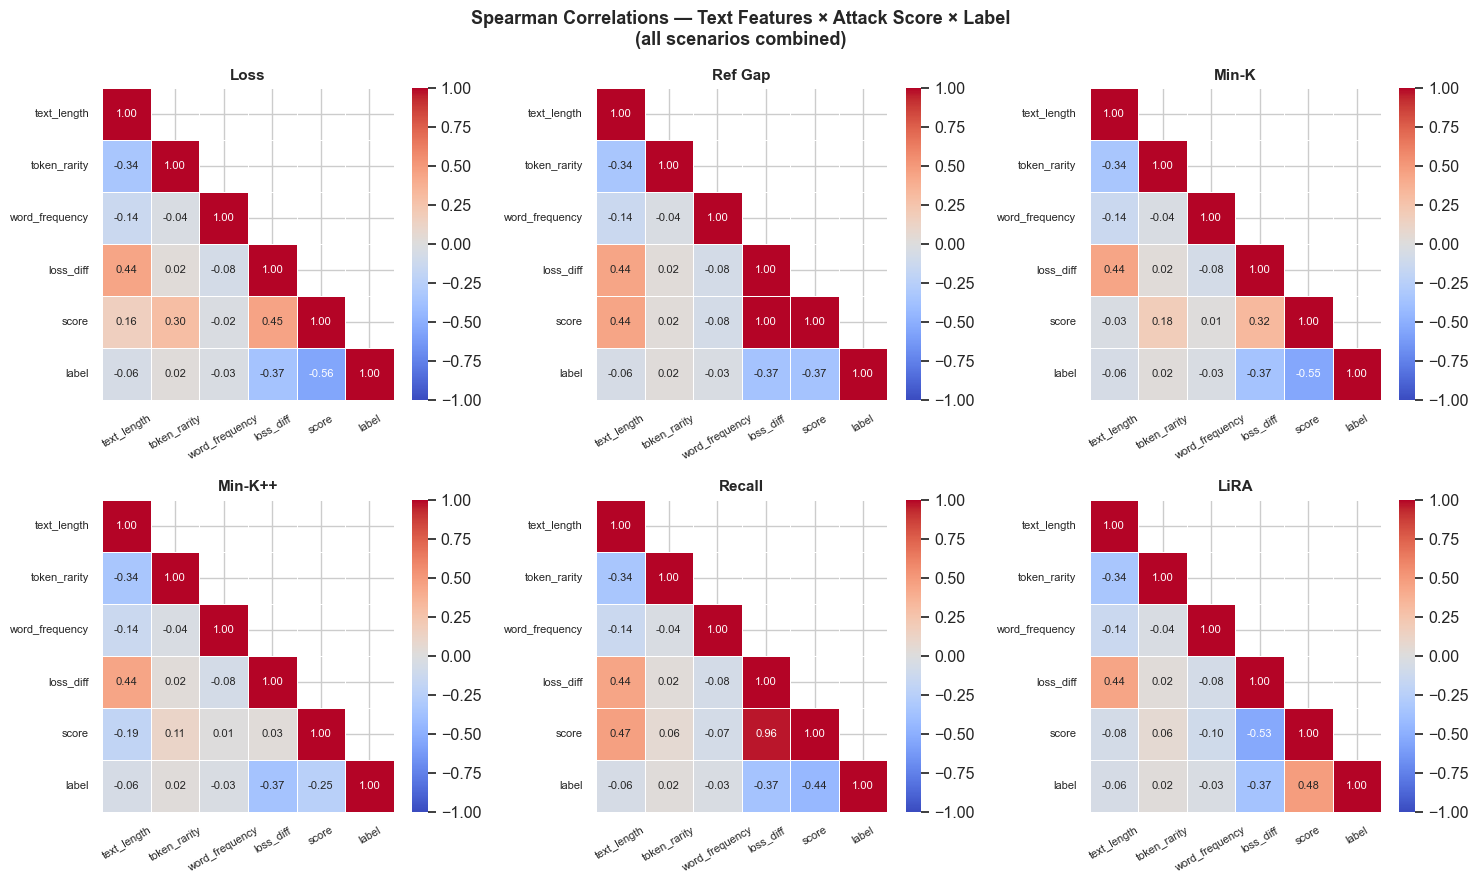


→ 'score' vs 'label' Spearman ≈ signal strength of the attack.
  'text_length' vs 'label' tells you if longer texts are more vulnerable.


In [30]:
# ── Correlation matrix: features vs attack scores ─────────────────────────────
print("### Correlation heatmap — sample features vs attack scores\n")

if not sample_df.empty:
    numeric_features = ["text_length","token_rarity","word_frequency","loss_diff","score","label"]
    num_cols = [c for c in numeric_features if c in sample_df.columns]

    # Per attack
    attacks_avail = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]
                     if a in sample_df["attack"].unique()]
    
    n_attacks = len(attacks_avail)
    ncols_plot = min(3, n_attacks)
    nrows_plot = (n_attacks + ncols_plot - 1) // ncols_plot
    
    fig, axes = plt.subplots(nrows_plot, ncols_plot, figsize=(ncols_plot*5, nrows_plot*4.5))
    axes = np.array(axes).flatten() if n_attacks > 1 else [axes]

    for ax, attack in zip(axes, attacks_avail):
        sub = sample_df[sample_df["attack"] == attack][num_cols].dropna()
        if sub.empty:
            ax.set_visible(False)
            continue
        corr = sub.corr(method="spearman")
        mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
        sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                    vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5,
                    annot_kws={"size": 8})
        ax.set_title(f"{ATTACK_LABELS.get(attack,attack)}", fontsize=11, fontweight="bold")
        ax.tick_params(axis="x", rotation=30, labelsize=8)
        ax.tick_params(axis="y", rotation=0, labelsize=8)

    # Hide unused subplots
    for ax in axes[len(attacks_avail):]:
        ax.set_visible(False)

    fig.suptitle("Spearman Correlations — Text Features × Attack Score × Label\n"
                 "(all scenarios combined)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("\n→ 'score' vs 'label' Spearman ≈ signal strength of the attack.")
    print("  'text_length' vs 'label' tells you if longer texts are more vulnerable.")


### Loss Gap: Target Model vs Reference Model

The reference gap attack exploits: loss_target < loss_reference → member.



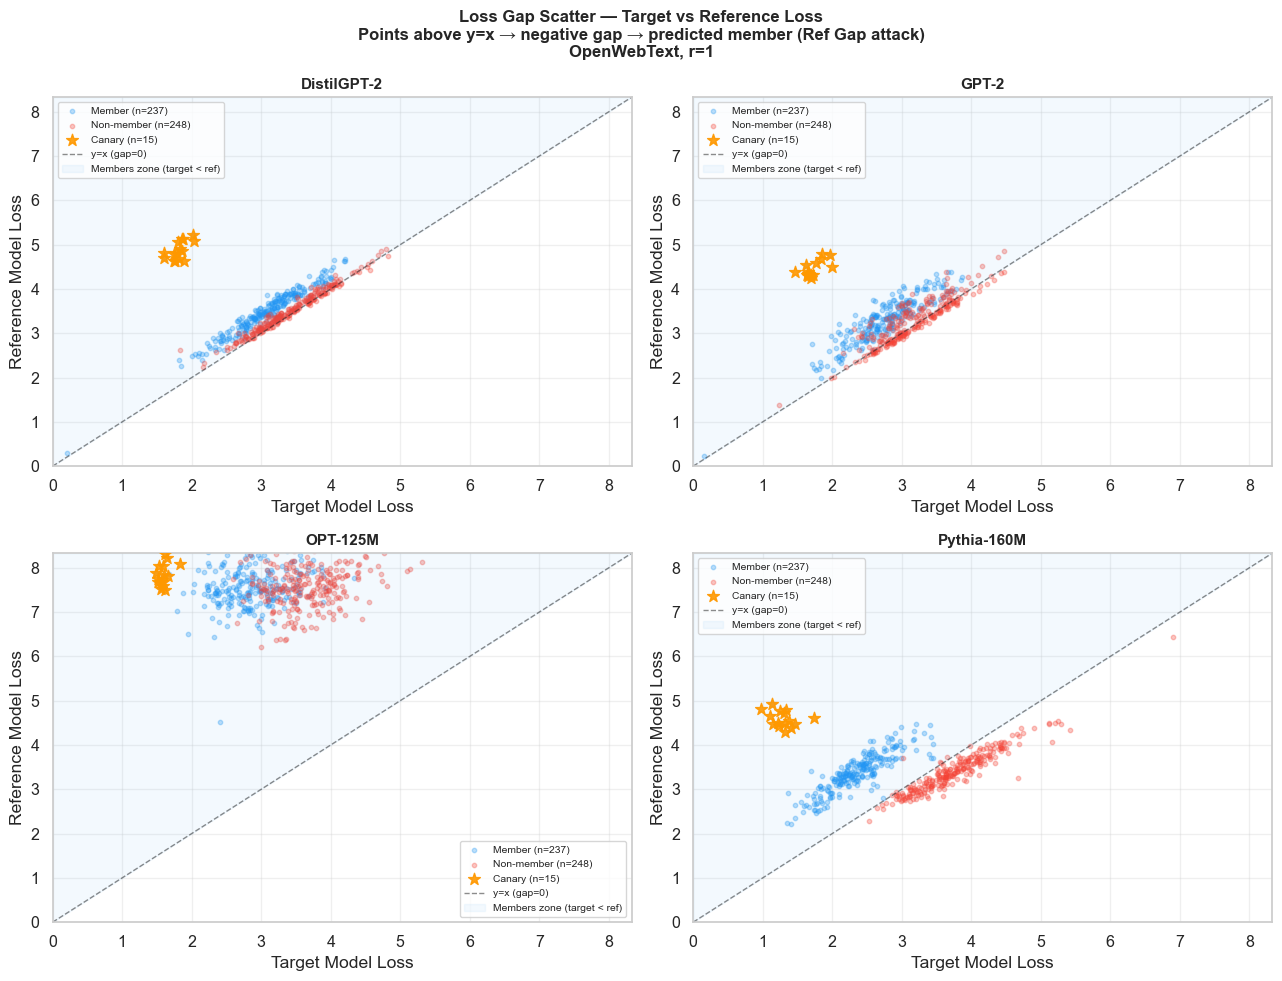

In [31]:
# ── Loss gap analysis: target loss vs reference loss ─────────────────────────
print("### Loss Gap: Target Model vs Reference Model\n")
print("The reference gap attack exploits: loss_target < loss_reference → member.\n")

if not sample_df.empty and "target_loss" in sample_df.columns and "ref_loss" in sample_df.columns:
    sub = sample_df[
        (sample_df["dataset_clean"] == "openwebtext") &
        (sample_df["canary_rep_int"] == 1) &
        (sample_df["attack"] == "ref_gap")
    ].copy()

    if not sub.empty:
        # Clip extreme values
        sub["target_loss"] = sub["target_loss"].clip(0, 10)
        sub["ref_loss"]    = sub["ref_loss"].clip(0, 10)

        fig, axes = plt.subplots(2, 2, figsize=(13, 10))

        for ax, model in zip(axes.flatten(), MODELS_ORDER):
            pool = sub[sub["model_full"] == model]
            d = pool.sample(min(500, len(pool)), random_state=42)
            if d.empty:
                ax.set_visible(False)
                continue

            colors = {1: "#2196F3", 0: "#F44336"}
            for label, label_name, src_filter in [
                (1, "Member", "train"),
                (0, "Non-member", "test"),
            ]:
                dd = d[d["source"] == src_filter]
                ax.scatter(dd["target_loss"], dd["ref_loss"],
                           alpha=0.3, s=10, c=colors[label], label=f"{label_name} (n={len(dd)})")

            # Canaries
            dc = d[d["source"] == "canary"]
            ax.scatter(dc["target_loss"], dc["ref_loss"],
                       alpha=0.9, s=80, marker="*", c="#FF9800", zorder=5,
                       label=f"Canary (n={len(dc)})")

            # y=x line (where ref gap = 0)
            lim = max(sub["target_loss"].quantile(0.99), sub["ref_loss"].quantile(0.99))
            ax.plot([0, lim], [0, lim], "k--", lw=1, alpha=0.5, label="y=x (gap=0)")
            # Member zone: target_loss < ref_loss  →  y > x  →  UPPER triangle
            ax.fill_between([0, lim], [0, lim], [lim, lim], alpha=0.05, color="#2196F3",
                            label="Members zone (target < ref)")
            ax.set_xlim(0, lim); ax.set_ylim(0, lim)
            ax.set_xlabel("Target Model Loss"); ax.set_ylabel("Reference Model Loss")
            ax.set_title(MODEL_LABELS.get(model, model), fontsize=11, fontweight="bold")
            ax.legend(fontsize=7.5)
            ax.grid(alpha=0.3)

        fig.suptitle("Loss Gap Scatter — Target vs Reference Loss\n"
                     "Points above y=x → negative gap → predicted member (Ref Gap attack)\n"
                     "OpenWebText, r=1",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()


### Detection rate by text length — are longer texts more vulnerable?



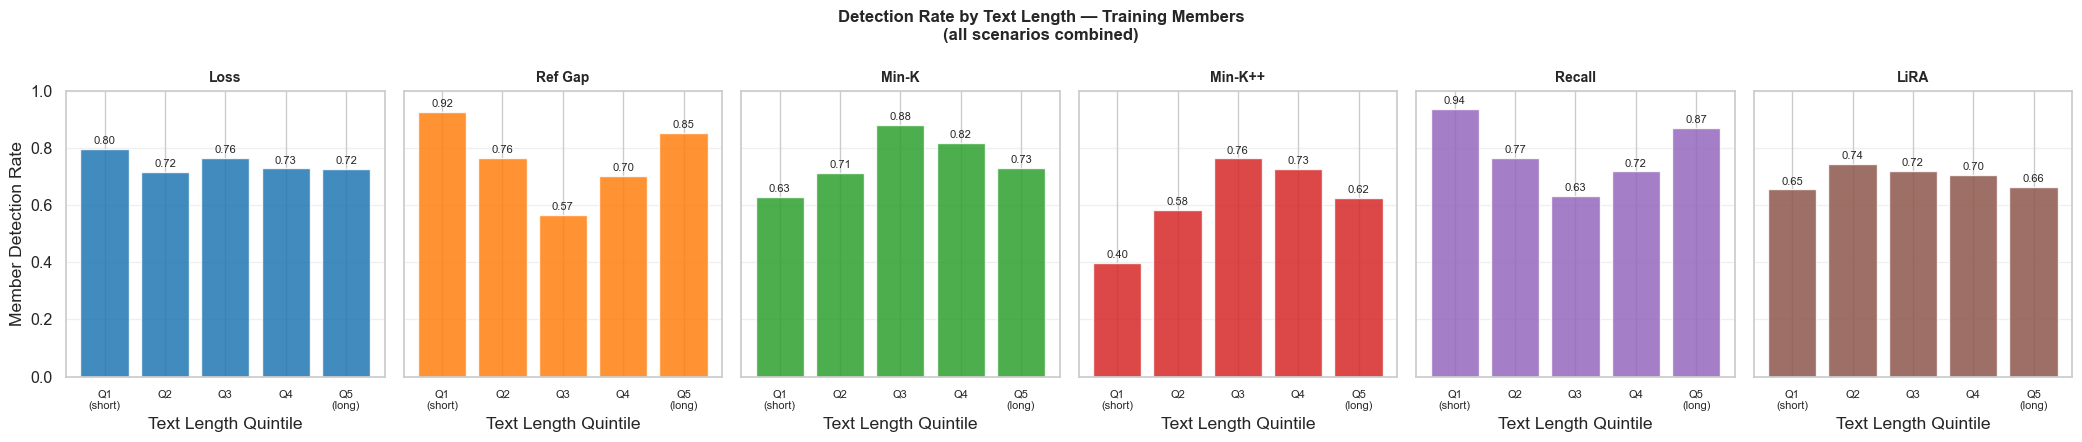


→ If detection rate rises with length, the attack may be length-biased.


In [32]:
# ── Vulnerability by text length buckets ─────────────────────────────────────
print("### Detection rate by text length — are longer texts more vulnerable?\n")

if not sample_df.empty and "text_length" in sample_df.columns:
    # Use members only; across all scenarios
    members = sample_df[sample_df["source"] == "train"].copy()
    members["length_bucket"] = pd.qcut(members["text_length"].clip(1, members["text_length"].quantile(0.99)),
                                       q=5, labels=["Q1\n(short)","Q2","Q3","Q4","Q5\n(long)"])

    # Detection rate = mean prediction per attack
    attacks_avail = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]
                     if a in members["attack"].unique()]

    fig, axes = plt.subplots(1, len(attacks_avail), figsize=(3.5*len(attacks_avail), 4.5), sharey=True)
    if len(attacks_avail) == 1:
        axes = [axes]

    for ax, attack in zip(axes, attacks_avail):
        d = members[members["attack"] == attack]
        det_by_len = d.groupby("length_bucket")["prediction"].mean().reset_index()
        ax.bar(range(len(det_by_len)), det_by_len["prediction"],
               color=ATTACK_COLORS[attack], alpha=0.85)
        ax.set_xticks(range(len(det_by_len)))
        ax.set_xticklabels(det_by_len["length_bucket"].astype(str), fontsize=8)
        ax.set_ylim(0, 1.0)
        ax.set_title(ATTACK_LABELS.get(attack,attack), fontsize=10, fontweight="bold")
        ax.set_xlabel("Text Length Quintile")
        if attack == attacks_avail[0]:
            ax.set_ylabel("Member Detection Rate")
        ax.grid(axis="y", alpha=0.3)
        # Add values on bars
        for i, v in enumerate(det_by_len["prediction"]):
            ax.text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    fig.suptitle("Detection Rate by Text Length — Training Members\n(all scenarios combined)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("\n→ If detection rate rises with length, the attack may be length-biased.")


### Token Rarity vs Detection Rate — are rare-token texts more vulnerable?



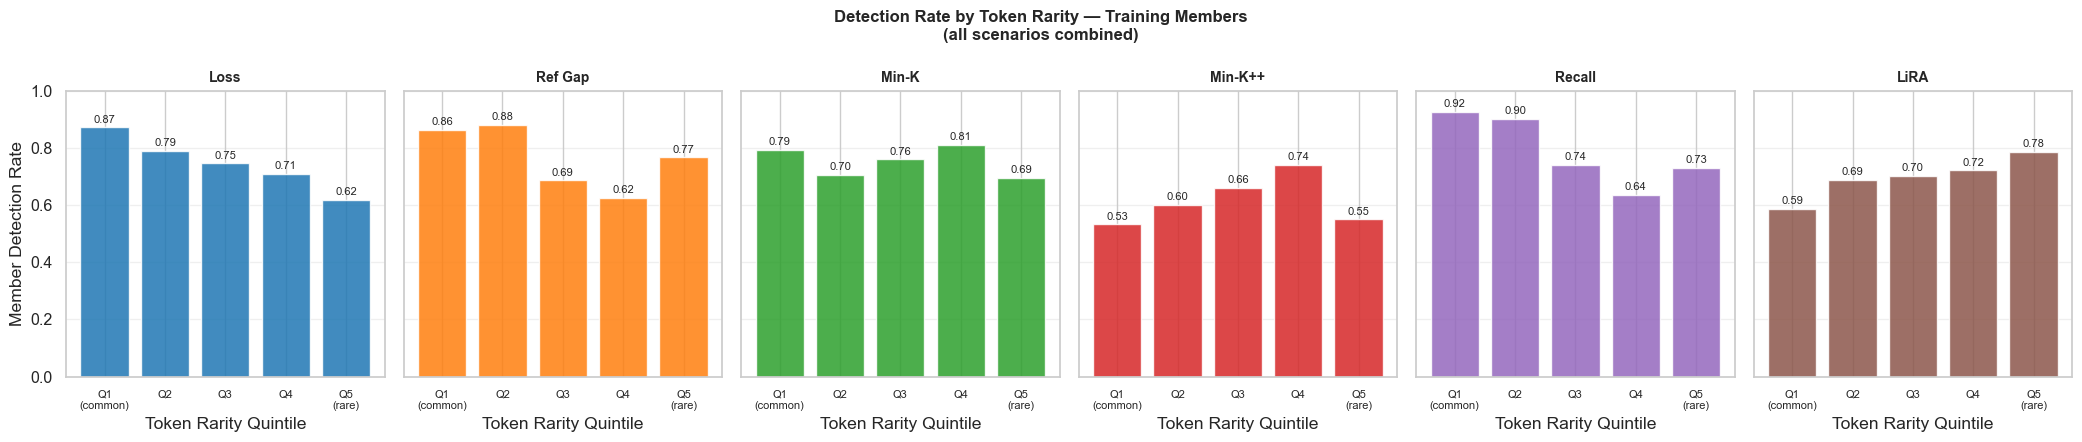


→ Min-K attacks specifically target the rarest tokens,
  so we expect a stronger rarity effect there.


In [33]:
# ── Token rarity vs vulnerability ────────────────────────────────────────────
print("### Token Rarity vs Detection Rate — are rare-token texts more vulnerable?\n")

if not sample_df.empty and "token_rarity" in sample_df.columns:
    members = sample_df[(sample_df["source"] == "train")].copy()
    members["rarity_bucket"] = pd.qcut(
        members["token_rarity"].clip(members["token_rarity"].quantile(0.01),
                                     members["token_rarity"].quantile(0.99)),
        q=5, labels=["Q1\n(common)","Q2","Q3","Q4","Q5\n(rare)"])

    attacks_avail = [a for a in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]
                     if a in members["attack"].unique()]

    fig, axes = plt.subplots(1, len(attacks_avail), figsize=(3.5*len(attacks_avail), 4.5), sharey=True)
    if len(attacks_avail) == 1: axes = [axes]

    for ax, attack in zip(axes, attacks_avail):
        d = members[members["attack"] == attack]
        det_by_rar = d.groupby("rarity_bucket")["prediction"].mean().reset_index()
        ax.bar(range(len(det_by_rar)), det_by_rar["prediction"],
               color=ATTACK_COLORS[attack], alpha=0.85)
        ax.set_xticks(range(len(det_by_rar)))
        ax.set_xticklabels(det_by_rar["rarity_bucket"].astype(str), fontsize=8)
        ax.set_ylim(0, 1.0)
        ax.set_title(ATTACK_LABELS.get(attack,attack), fontsize=10, fontweight="bold")
        ax.set_xlabel("Token Rarity Quintile")
        if attack == attacks_avail[0]:
            ax.set_ylabel("Member Detection Rate")
        ax.grid(axis="y", alpha=0.3)
        for i, v in enumerate(det_by_rar["prediction"]):
            ax.text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=8)

    fig.suptitle("Detection Rate by Token Rarity — Training Members\n(all scenarios combined)",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("\n→ Min-K attacks specifically target the rarest tokens,")
    print("  so we expect a stronger rarity effect there.")


## 11. Summary Ranking & Practical Guidance

A unified ranking table and radar charts consolidating all metrics into a practical guide: which attack to choose for which scenario.

### Comprehensive Attack Leaderboard

Metric averages across ALL scenarios (models, datasets, reps):



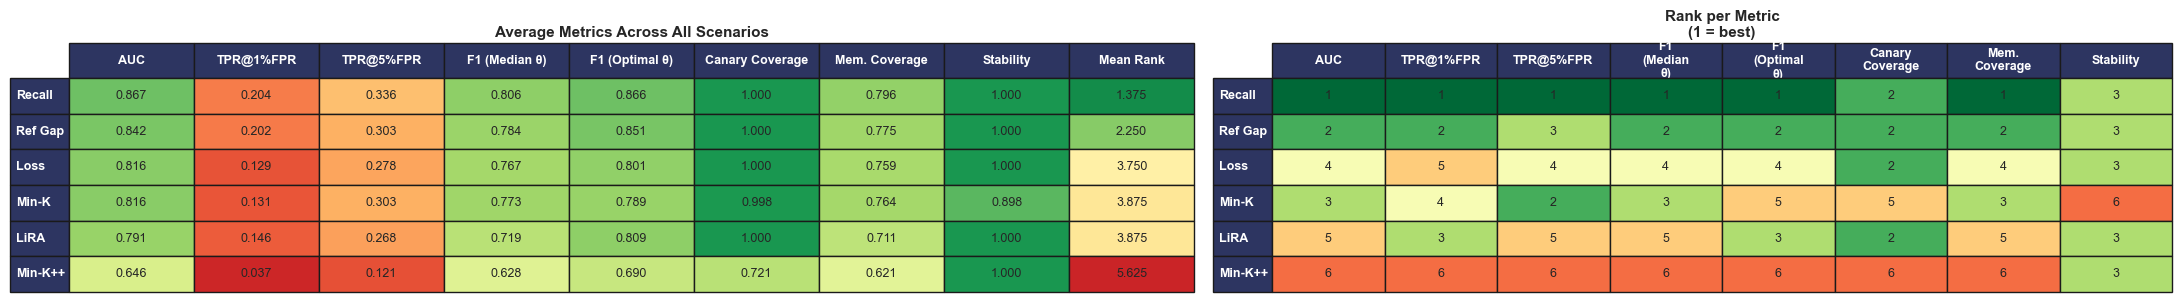

In [35]:
# ── Multi-metric leaderboard ──────────────────────────────────────────────────
print("### Comprehensive Attack Leaderboard\n")

rank_metrics = {
    "AUC":            "auc",
    "TPR@1%FPR":      "tpr@fpr=0.01",
    "TPR@5%FPR":      "tpr@fpr=0.05",
    "F1 (Median θ)":  "f1_median",
    "F1 (Optimal θ)": "f1_f1",
    "Canary Coverage":"coverage_canaries",
    "Mem. Coverage":  "coverage_all_members",
    "Stability":      "stability",
}

# Overall leaderboard (avg over all scenarios)
lb_rows = []
for attack in ["loss","ref_gap","min_k","min_k_pp","recall","lira"]:
    sub = metrics_df[metrics_df["attack"] == attack]
    row = {"Attack": ATTACK_LABELS.get(attack, attack)}
    for label, col in rank_metrics.items():
        row[label] = sub[col].mean() if col in sub.columns else np.nan
    lb_rows.append(row)

lb_df = pd.DataFrame(lb_rows).set_index("Attack")

# Rank each metric (1 = best)
rank_df = lb_df.rank(ascending=False).astype(int)
rank_df["Mean Rank"] = rank_df.mean(axis=1)
lb_df["Mean Rank"] = rank_df["Mean Rank"]
lb_df = lb_df.sort_values("Mean Rank")
rank_df = rank_df.reindex(lb_df.index)

print("Metric averages across ALL scenarios (models, datasets, reps):\n")

# Wider figure + more space for right panel to avoid column-name compression
fig, axes = plt.subplots(1, 2, figsize=(22, 3.2), gridspec_kw={"width_ratios": [2, 1.6]})

# Left: absolute values
ax = axes[0]
ax.axis("off")
cell_text = [[f"{lb_df.loc[atk, col]:.3f}" for col in lb_df.columns] for atk in lb_df.index]
tbl = ax.table(cellText=cell_text,
               rowLabels=lb_df.index.tolist(),
               colLabels=lb_df.columns.tolist(),
               cellLoc="center", bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1)
for (row, col), cell in tbl.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2d3561")
        cell.set_text_props(color="white", fontweight="bold")
    elif col < len(rank_metrics):
        try:
            v = float(cell.get_text().get_text())
            cell.set_facecolor(plt.cm.RdYlGn(min(max(v, 0), 1) * 0.85 + 0.05))
        except ValueError:
            pass
    else:  # Mean Rank column
        try:
            v = float(cell.get_text().get_text())
            cell.set_facecolor(plt.cm.RdYlGn_r(min(max((v-1)/5, 0), 1)))
        except ValueError:
            pass
ax.set_title("Average Metrics Across All Scenarios", fontsize=11, fontweight="bold", pad=4)

# Right: ranks only
ax = axes[1]
ax.axis("off")
rank_display = rank_df.drop(columns=["Mean Rank"]) if "Mean Rank" in rank_df.columns else rank_df
cell_ranks = [[str(rank_df.loc[atk, col]) for col in rank_display.columns] for atk in rank_display.index]
tbl2 = ax.table(cellText=cell_ranks,
                rowLabels=rank_display.index.tolist(),
                colLabels=[c.replace(" ", "\n") for c in rank_display.columns],
                cellLoc="center", bbox=[0, 0, 1, 1])
tbl2.auto_set_font_size(False); tbl2.set_fontsize(9); tbl2.scale(1, 1)
for (row, col), cell in tbl2.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2d3561")
        cell.set_text_props(color="white", fontweight="bold")
    else:
        try:
            v = int(cell.get_text().get_text())
            n = len(rank_display.index)
            cell.set_facecolor(plt.cm.RdYlGn(1.0 - (v-1)/(n-1) * 0.8))
        except ValueError:
            pass
ax.set_title("Rank per Metric\n(1 = best)", fontsize=11, fontweight="bold", pad=4)

plt.tight_layout()
plt.show()


### Radar Charts — Multi-dimensional attack fingerprints



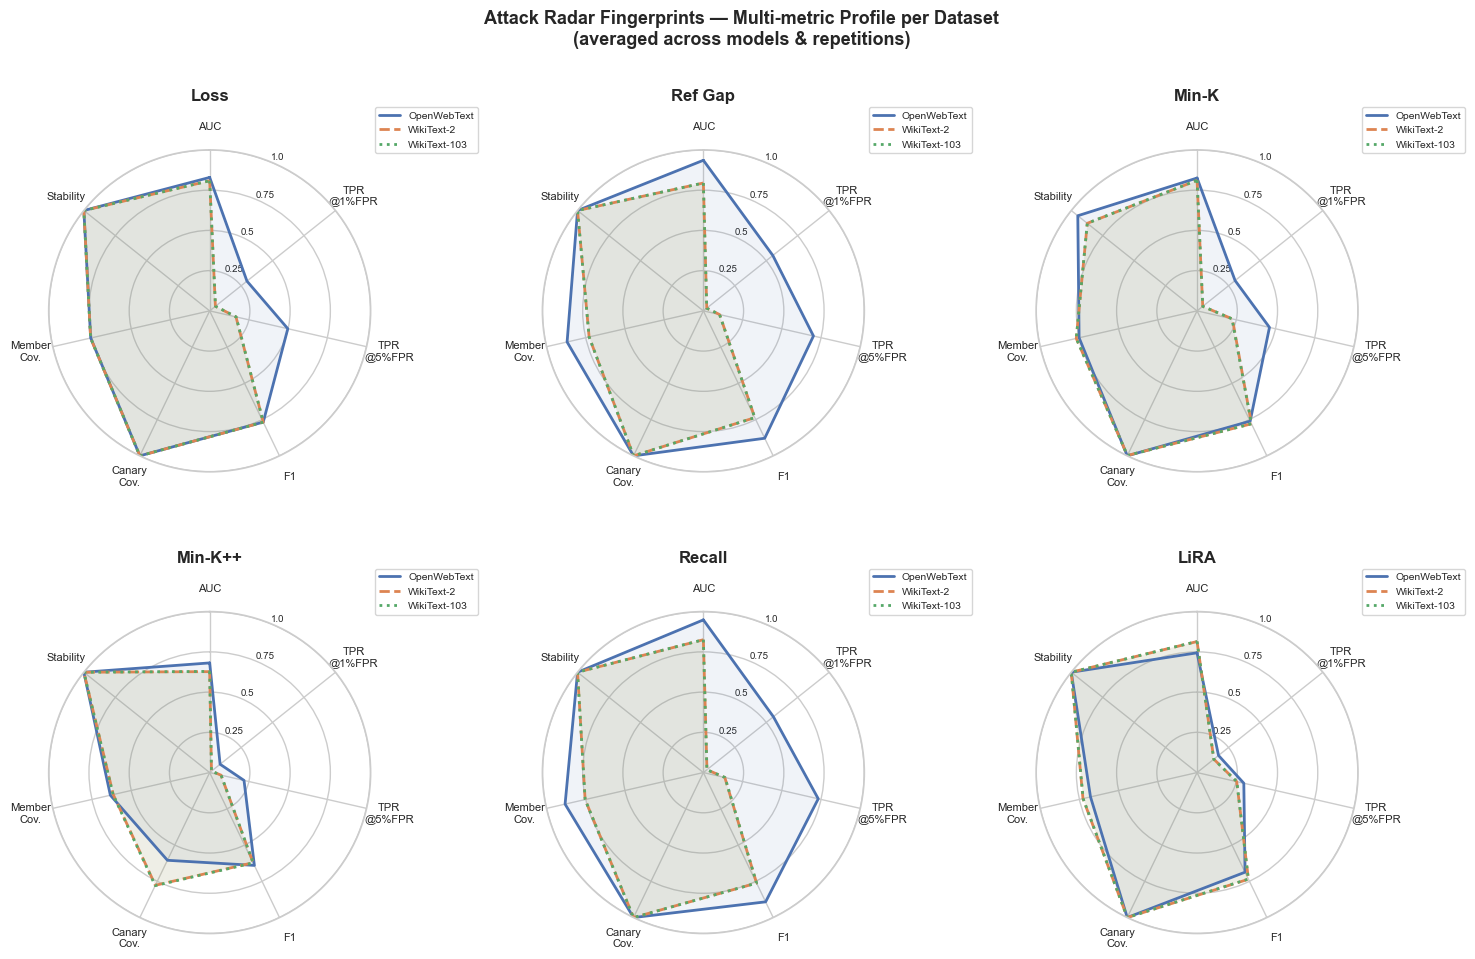

In [36]:
# ── Radar charts: multi-dimensional attack fingerprints ──────────────────────
print("### Radar Charts — Multi-dimensional attack fingerprints\n")

radar_metrics = ["auc", "tpr@fpr=0.01", "tpr@fpr=0.05", "f1", "coverage_canaries",
                 "coverage_all_members", "stability"]
radar_labels  = ["AUC", "TPR\n@1%FPR", "TPR\n@5%FPR", "F1", "Canary\nCov.", "Member\nCov.", "Stability"]

N = len(radar_metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

attacks_order = ["loss","ref_gap","min_k","min_k_pp","recall","lira"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10), subplot_kw=dict(polar=True))

for ax, attack in zip(axes.flatten(), attacks_order):
    sub = metrics_df[metrics_df["attack"] == attack]

    # Per dataset
    for dataset, style in [
        ("openwebtext",         "-"),
        ("wikitext-2-raw-v1",   "--"),
        ("wikitext-103-raw-v1", ":"),
    ]:
        d = sub[sub["dataset"] == dataset]
        if d.empty:
            continue
        vals = [float(d[m].mean()) if m in d.columns else 0 for m in radar_metrics]
        vals_plot = vals + [vals[0]]
        ds_label = DATASET_LABELS.get(dataset, dataset)
        ax.plot(angles, vals_plot, lw=2, ls=style, label=ds_label)
        ax.fill(angles, vals_plot, alpha=0.08)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25","0.5","0.75","1.0"], fontsize=7)
    ax.set_title(ATTACK_LABELS.get(attack, attack), fontsize=12, fontweight="bold", pad=15)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=7.5)

fig.suptitle("Attack Radar Fingerprints — Multi-metric Profile per Dataset\n(averaged across models & repetitions)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### Which attack is best for each scenario?

Attack win counts by AUC:
Best (AUC)
LiRA       21
Recall     16
Ref Gap     8
Loss        3

Attack win counts by TPR@1%FPR:
Best (TPR@1%)
LiRA       32
Ref Gap    10
Recall      4
Loss        2


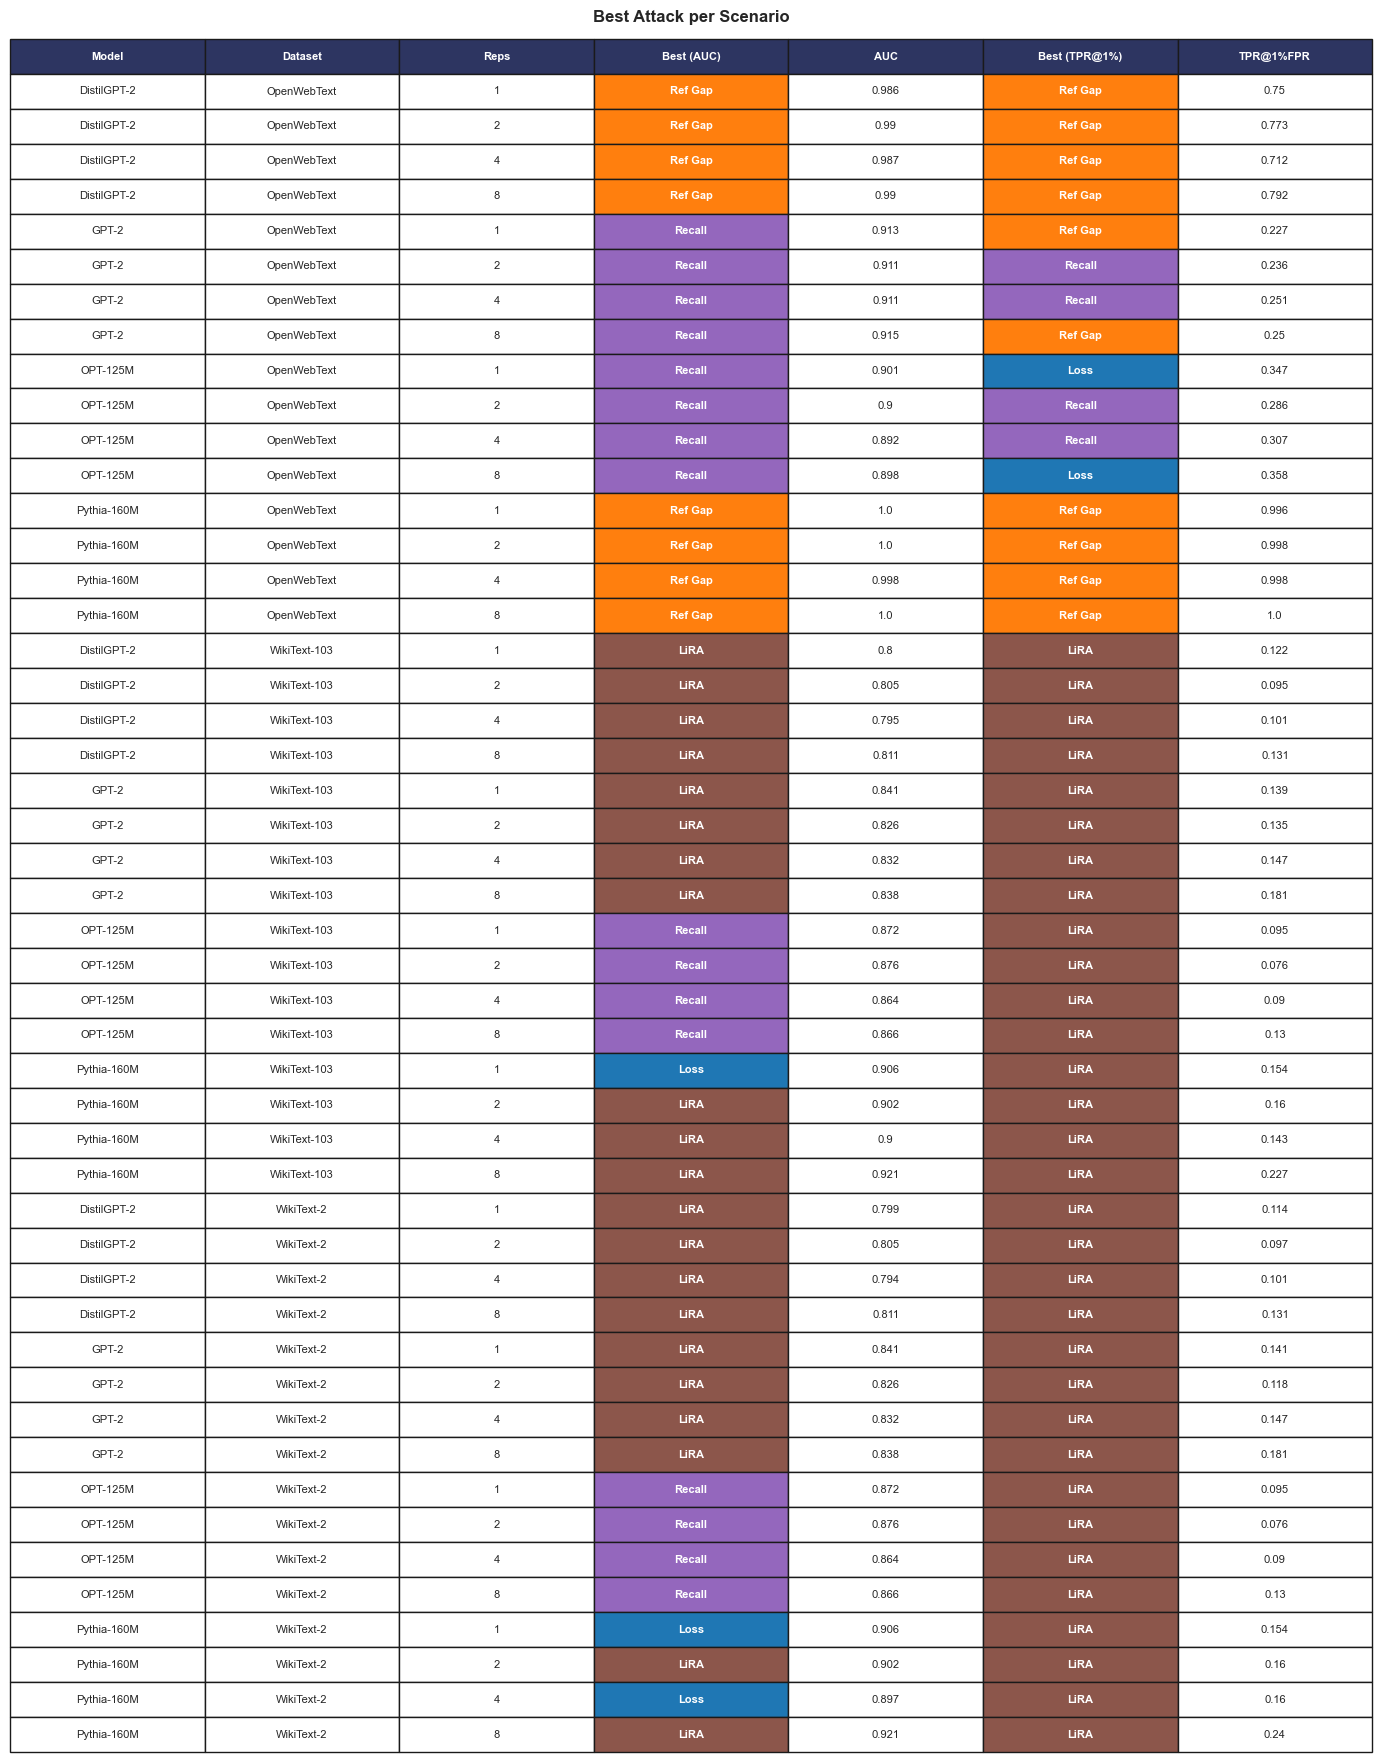

In [37]:
# ── Per-scenario best attack table ────────────────────────────────────────────
print("### Which attack is best for each scenario?\n")

best_attack_rows = []
for (model, dataset, rep), grp in metrics_df.groupby(["model_short","dataset","canary_rep"]):
    # Best by AUC
    best_auc_row = grp.loc[grp["auc"].idxmax()] if not grp["auc"].isna().all() else None
    best_tpr_row = grp.loc[grp["tpr@fpr=0.01"].idxmax()] if not grp["tpr@fpr=0.01"].isna().all() else None
    best_attack_rows.append({
        "Model":       MODEL_LABELS.get(model, model),
        "Dataset":     DATASET_LABELS.get(dataset, dataset),
        "Reps":        rep,
        "Best (AUC)":  ATTACK_LABELS.get(best_auc_row["attack"], "") if best_auc_row is not None else "",
        "AUC":         round(best_auc_row["auc"], 3) if best_auc_row is not None else np.nan,
        "Best (TPR@1%)": ATTACK_LABELS.get(best_tpr_row["attack"], "") if best_tpr_row is not None else "",
        "TPR@1%FPR":   round(best_tpr_row["tpr@fpr=0.01"], 3) if best_tpr_row is not None else np.nan,
    })

best_df = pd.DataFrame(best_attack_rows).sort_values(["Dataset","Model","Reps"])

# Count how often each attack wins
print("Attack win counts by AUC:")
print(best_df["Best (AUC)"].value_counts().to_string())
print("\nAttack win counts by TPR@1%FPR:")
print(best_df["Best (TPR@1%)"].value_counts().to_string())

# Display table
fig, ax = plt.subplots(figsize=(14, max(4, len(best_df) * 0.35 + 1)))
ax.axis("off")
tbl = ax.table(
    cellText=best_df.values,
    colLabels=best_df.columns.tolist(),
    cellLoc="center", loc="upper center",
    bbox=[0, 0, 1, 0.995],
)
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1.0, 1.35)
attack_colors_display = {v: k for k, v in ATTACK_LABELS.items()}
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_facecolor("#2d3561")
        cell.set_text_props(color="white", fontweight="bold")
    elif col in [3, 5]:  # Best attack columns
        txt = cell.get_text().get_text()
        orig = attack_colors_display.get(txt, "")
        if orig in ATTACK_COLORS:
            cell.set_facecolor(ATTACK_COLORS[orig])
            cell.set_text_props(color="white", fontweight="bold")

ax.set_title("Best Attack per Scenario", fontsize=12, fontweight="bold",
             loc="center", y=1.0)
plt.tight_layout()
plt.show()


### Summary: All metrics side by side per attack



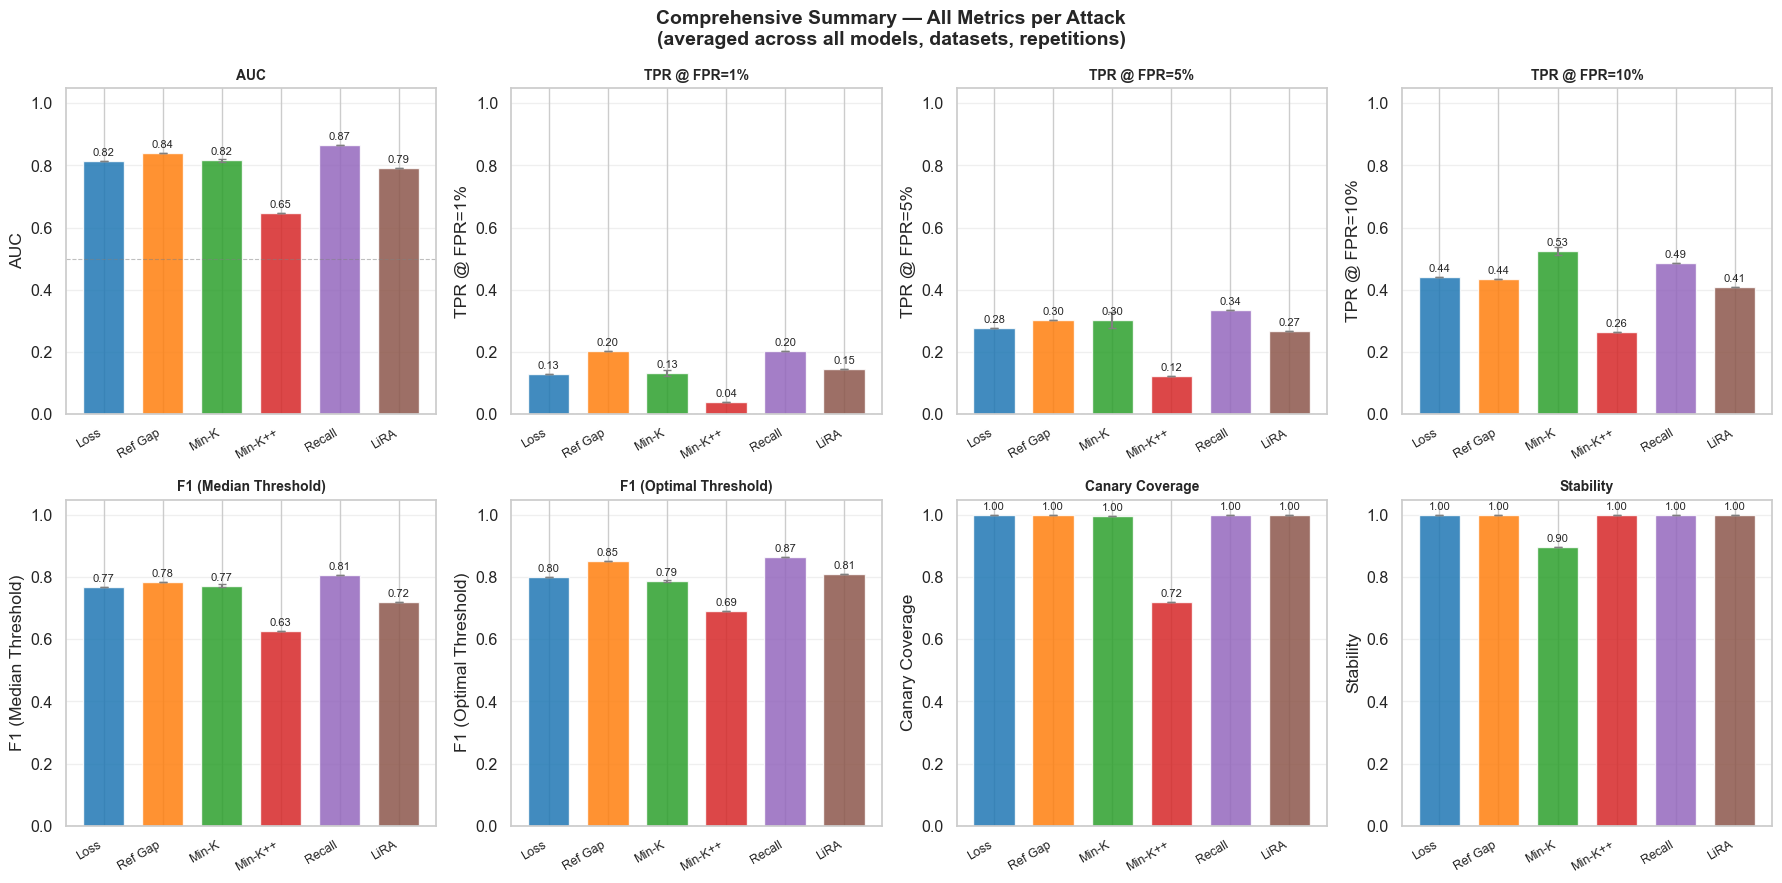

In [38]:
# ── Final summary bar chart ───────────────────────────────────────────────────
print("### Summary: All metrics side by side per attack\n")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
plot_metrics = [
    ("auc",                "AUC"),
    ("tpr@fpr=0.01",       "TPR @ FPR=1%"),
    ("tpr@fpr=0.05",       "TPR @ FPR=5%"),
    ("tpr@fpr=0.10",       "TPR @ FPR=10%"),
    ("f1_median",          "F1 (Median Threshold)"),
    ("f1_f1",              "F1 (Optimal Threshold)"),
    ("coverage_canaries",  "Canary Coverage"),
    ("stability",          "Stability"),
]

attacks_order = ["loss","ref_gap","min_k","min_k_pp","recall","lira"]
x = np.arange(len(attacks_order))
colors = [ATTACK_COLORS[a] for a in attacks_order]

for ax, (metric, label) in zip(axes.flatten(), plot_metrics):
    vals = []
    errs = []
    for attack in attacks_order:
        sub = metrics_df[metrics_df["attack"] == attack]
        vals.append(sub[metric].mean() if metric in sub.columns else 0)
        errs.append(sub[metric + "_std"].mean() if (metric + "_std") in sub.columns else 0)
    bars = ax.bar(x, vals, color=colors, alpha=0.85, width=0.7,
                  yerr=errs, capsize=3, ecolor="grey")
    ax.axhline(0.5 if "auc" in metric else 0, color="grey", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([ATTACK_LABELS.get(a,"") for a in attacks_order], rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_ylabel(label)
    ax.grid(axis="y", alpha=0.3)
    # Value annotations
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.2f}",
                    ha="center", va="bottom", fontsize=8)

fig.suptitle("Comprehensive Summary — All Metrics per Attack\n(averaged across all models, datasets, repetitions)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


---

## Key Takeaways

This notebook goes beyond single-number AUC reporting to examine **how**, **where**, and **why** membership inference attacks succeed or fail:

1. **AUC is not enough** — Two attacks with similar AUC can have very different precision–recall profiles, different TPR @ low FPR, and different threshold sensitivity.

2. **Score distributions reveal the mechanism** — Ref Gap and Recall attacks create clear bimodal separation between members and non-members; simple Loss has substantial overlap.

3. **Canaries ≠ regular members** — High canary coverage does not imply high general member coverage. Some attacks exploit repetition-induced memorisation specifically; others find regular members but miss canaries.

4. **More repetitions help some attacks more than others** — The rate of improvement with r=1→8 varies dramatically by attack type and dataset.

5. **Datasets matter as much as models** — Certain dataset/attack combinations consistently fail regardless of model size.

6. **Sample vulnerability is predictable** — Text length, token rarity, and the target–reference loss gap are measurable predictors of MIA detectability.

7. **Threshold choice is non-trivial** — The F1 gap between median and optimal thresholds reveals how much headroom some attacks have when tuned correctly.

8. **Pre-training domain affinity breaks LiRA's calibration** — LiRA (AUC = 0.32) performs *below random* on OPT-125m + OpenWebText, despite working well on other datasets. OPT was pre-trained on web-crawl data (The Pile), so its loss on OpenWebText texts is already low before fine-tuning. Shadow models trained for half the epochs on half the data can't distinguish "this text was memorised" from "this text is just easy web content the target's extra training reinforced globally." The z-score ranking inverts: common web-domain non-members receive higher scores than actual members. This is a principled failure of shadow-model calibration when the pre-training and fine-tuning distributions substantially overlap.
